In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    roc_curve, precision_recall_curve, average_precision_score,
    ConfusionMatrixDisplay
)
from sklearn.preprocessing import LabelEncoder
from sklearn.inspection import permutation_importance

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'DejaVu Sans'
SEED = 42
print('Libraries loaded ✓')

Libraries loaded ✓


In [ ]:
df_raw = pd.read_csv('full_combined_dataset.csv', low_memory=False)
print(f'Raw dataset shape: {df_raw.shape}')
print(f'\nPitchCall distribution:')
print(df_raw['PitchCall'].value_counts())

Raw dataset shape: (33741, 197)

PitchCall distribution:
PitchCall
BallCalled              12384
StrikeCalled             6074
InPlay                   5774
FoulBallNotFieldable     3996
StrikeSwinging           3354
BallinDirt                756
FoulBall                  735
HitByPitch                346
Undefined                 202
FoulBallFieldable         103
BallIntentional            17
Name: count, dtype: int64


In [ ]:
# ── Target: 1 = swinging strike, 0 = everything else ──────────────────────
df_raw['swing_and_miss'] = (df_raw['PitchCall'] == 'StrikeSwinging').astype(int)
print(f"Swing-and-miss rate: {df_raw['swing_and_miss'].mean():.3f}  "
      f"({df_raw['swing_and_miss'].sum():,} / {len(df_raw):,} pitches)")

# ── Feature selection ─────────────────────────────────────────────────────
# Pitch physics
PITCH_PHYSICS = [
    'RelSpeed',           # release speed (mph)
    'EffectiveVelo',      # perceived velocity accounting for extension
    'SpinRate',           # spin rate (rpm)
    'SpinAxis',           # spin axis (degrees)
    'InducedVertBreak',   # induced vertical movement (in)
    'VertBreak',          # total vertical break (in)
    'HorzBreak',          # horizontal break (in)
    'VertApprAngle',      # vertical approach angle at plate
    'HorzApprAngle',      # horizontal approach angle at plate
    'Extension',          # release extension (ft)
    'RelHeight',          # release height (ft)
    'RelSide',            # release side (ft)
    'ZoneSpeed',          # speed as pitch crosses plate
    'ZoneTime',           # time from release to plate (s)
    'SpeedDrop',          # velo drop from release to plate
]

# Pitch location
LOCATION = [
    'PlateLocHeight',     # height at plate (ft from ground)
    'PlateLocSide',       # side at plate (ft from center)
]

# At-bat / count context (known at time of pitch)
CONTEXT = [
    'Balls',
    'Strikes',
    'Outs',
    'Inning',
    'PitchofPA',          # pitch number within the plate appearance
]

# Categorical matchup features
CATEGORICAL = [
    'TaggedPitchType',    # pitch type label
    'PitcherThrows',      # L/R
    'BatterSide',         # L/R
]

ALL_FEATURES = PITCH_PHYSICS + LOCATION + CONTEXT + CATEGORICAL

# ── Subset and drop rows with missing numeric features ────────────────────
df = df_raw[ALL_FEATURES + ['swing_and_miss']].copy()

# Drop 'Undefined' pitch type rows (no reliable label)
df = df[df['TaggedPitchType'].notna() & (df['TaggedPitchType'] != 'Undefined')]
df = df[df['PitcherThrows'].notna() & (~df['PitcherThrows'].isin(['Undefined', 'Both']))]
df = df[df['BatterSide'].notna()   & (~df['BatterSide'].isin(['Undefined']))]

numeric_features = PITCH_PHYSICS + LOCATION + CONTEXT
df = df.dropna(subset=['PlateLocHeight', 'PlateLocSide', 'RelSpeed'])  # require core location/velo

print(f'\nWorking dataset after filtering: {df.shape[0]:,} rows')
print(f'Swing-and-miss rate after filter: {df["swing_and_miss"].mean():.3f}')

Swing-and-miss rate: 0.099  (3,354 / 33,741 pitches)

Working dataset after filtering: 23,188 rows
Swing-and-miss rate after filter: 0.098


In [ ]:
# ── Derived features ──────────────────────────────────────────────────────

# Distance from strike zone center (roughly 0.0 side, 2.5 ft height)
df['zone_dist'] = np.sqrt(df['PlateLocSide']**2 + (df['PlateLocHeight'] - 2.5)**2)

# Total movement magnitude
df['total_break'] = np.sqrt(df['HorzBreak']**2 + df['InducedVertBreak']**2)

# Count leverage: 2-strike counts, hitter's counts
df['two_strike']   = (df['Strikes'] == 2).astype(int)
df['hitters_count']= (df['Balls'] > df['Strikes']).astype(int)

# Platoon matchup: same-side = 1, opposite = 0
df['same_side'] = (df['PitcherThrows'] == df['BatterSide']).astype(int)

ENGINEERED = ['zone_dist', 'total_break', 'two_strike', 'hitters_count', 'same_side']

# ── Encode categoricals ───────────────────────────────────────────────────
le_pitch = LabelEncoder()
le_hand  = LabelEncoder()
le_bat   = LabelEncoder()

df['pitch_type_enc']  = le_pitch.fit_transform(df['TaggedPitchType'].astype(str))
df['pitcher_hand_enc']= le_hand.fit_transform(df['PitcherThrows'].astype(str))
df['batter_side_enc'] = le_bat.fit_transform(df['BatterSide'].astype(str))

print('Pitch type classes:', list(zip(le_pitch.classes_, le_pitch.transform(le_pitch.classes_))))

FINAL_FEATURES = (numeric_features + ENGINEERED +
                  ['pitch_type_enc', 'pitcher_hand_enc', 'batter_side_enc'])

X = df[FINAL_FEATURES].copy()
y = df['swing_and_miss'].copy()

# Impute remaining numeric NaNs with column median
for col in X.columns:
    if X[col].isna().any():
        X[col] = X[col].fillna(X[col].median())

print(f'\nFinal feature matrix: {X.shape}')
print(f'Missing values remaining: {X.isna().sum().sum()}')

Pitch type classes: [('ChangeUp', np.int64(0)), ('Curveball', np.int64(1)), ('Cutter', np.int64(2)), ('Fastball', np.int64(3)), ('FourSeamFastBall', np.int64(4)), ('Knuckleball', np.int64(5)), ('OneSeamFastBall', np.int64(6)), ('Other', np.int64(7)), ('Sinker', np.int64(8)), ('Slider', np.int64(9)), ('Splitter', np.int64(10)), ('TwoSeamFastBall', np.int64(11))]

Final feature matrix: (23188, 30)
Missing values remaining: 0


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=SEED, stratify=y
)

print(f'Train: {X_train.shape[0]:,} rows  |  Test: {X_test.shape[0]:,} rows')
print(f'Train swing-and-miss rate: {y_train.mean():.3f}')
print(f'Test  swing-and-miss rate: {y_test.mean():.3f}')

Train: 18,550 rows  |  Test: 4,638 rows
Train swing-and-miss rate: 0.098
Test  swing-and-miss rate: 0.098


In [ ]:
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=12,
    min_samples_leaf=20,
    max_features='sqrt',
    class_weight='balanced',   # handles class imbalance (~10% positives)
    random_state=SEED,
    n_jobs=-1
)

rf.fit(X_train, y_train)
print('Model trained ✓')

# ── 5-fold CV AUC on training set ─────────────────────────────────────────
cv_scores = cross_val_score(rf, X_train, y_train, cv=5, scoring='roc_auc', n_jobs=-1)
print(f'\n5-Fold CV ROC-AUC: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')

Model trained ✓

5-Fold CV ROC-AUC: 0.7744 ± 0.0148


In [ ]:
y_pred  = rf.predict(X_test)
y_proba = rf.predict_proba(X_test)[:, 1]

roc_auc = roc_auc_score(y_test, y_proba)
avg_prec = average_precision_score(y_test, y_proba)

print('='*50)
print(f'  ROC-AUC:             {roc_auc:.4f}')
print(f'  Average Precision:   {avg_prec:.4f}')
print('='*50)
print()
print(classification_report(y_test, y_pred, target_names=['No SwM', 'Swing & Miss']))

  ROC-AUC:             0.7780
  Average Precision:   0.3026

              precision    recall  f1-score   support

      No SwM       0.94      0.88      0.91      4183
Swing & Miss       0.30      0.48      0.37       455

    accuracy                           0.84      4638
   macro avg       0.62      0.68      0.64      4638
weighted avg       0.88      0.84      0.85      4638



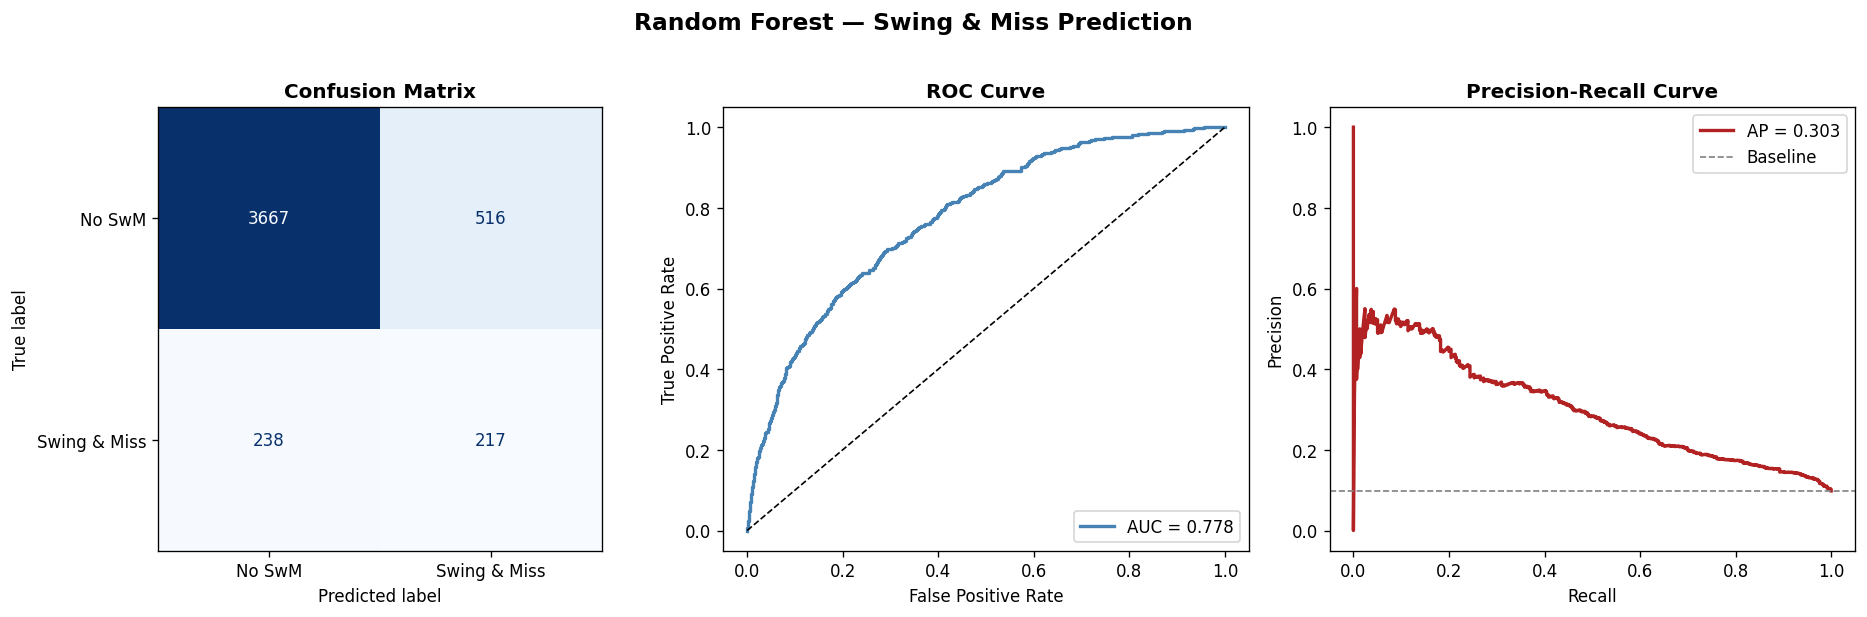

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# ── (a) Confusion Matrix ──────────────────────────────────────────────────
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=['No SwM', 'Swing & Miss'])
disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Confusion Matrix', fontweight='bold')

# ── (b) ROC Curve ─────────────────────────────────────────────────────────
fpr, tpr, _ = roc_curve(y_test, y_proba)
axes[1].plot(fpr, tpr, color='steelblue', lw=2, label=f'AUC = {roc_auc:.3f}')
axes[1].plot([0,1],[0,1],'k--', lw=1)
axes[1].set_xlabel('False Positive Rate'); axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve', fontweight='bold')
axes[1].legend(loc='lower right')

# ── (c) Precision-Recall Curve ────────────────────────────────────────────
prec, rec, _ = precision_recall_curve(y_test, y_proba)
axes[2].plot(rec, prec, color='firebrick', lw=2, label=f'AP = {avg_prec:.3f}')
axes[2].axhline(y_test.mean(), color='gray', linestyle='--', lw=1, label='Baseline')
axes[2].set_xlabel('Recall'); axes[2].set_ylabel('Precision')
axes[2].set_title('Precision-Recall Curve', fontweight='bold')
axes[2].legend()

plt.suptitle('Random Forest — Swing & Miss Prediction', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 7. Feature Importance

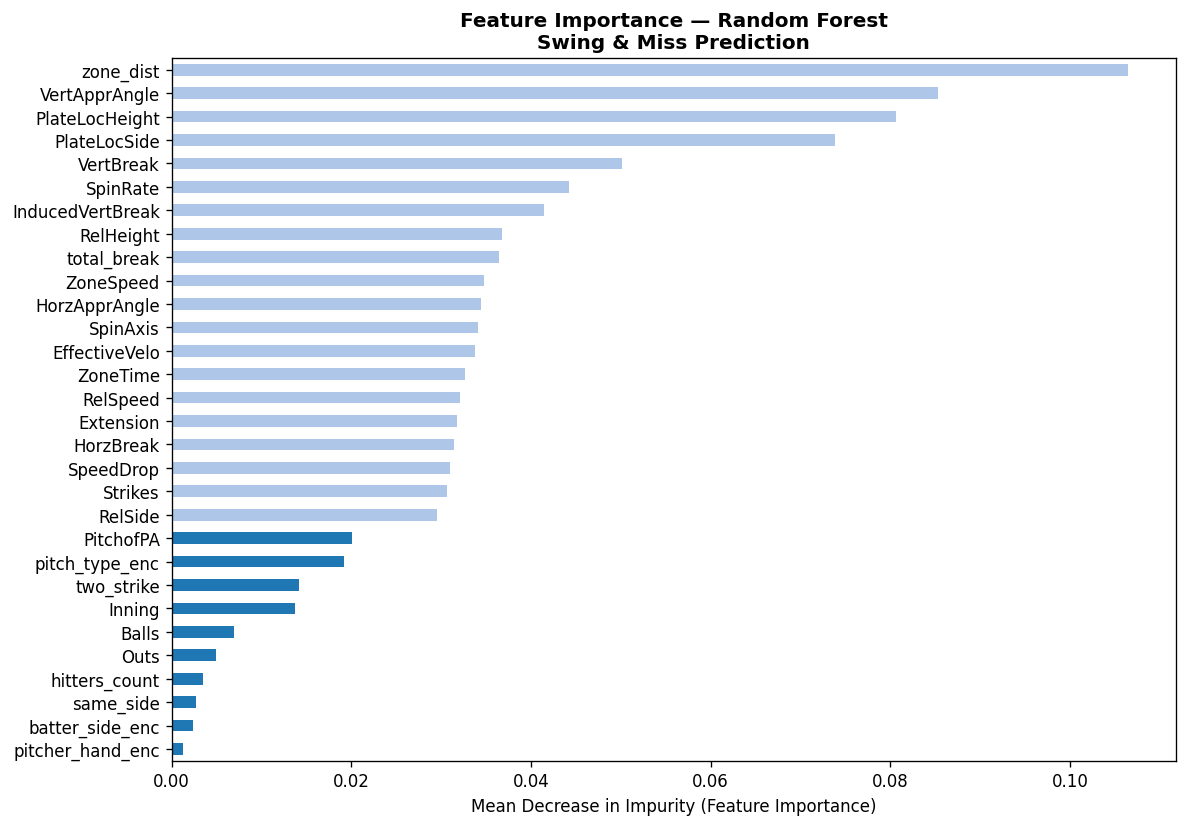

Top 10 features:
zone_dist           0.106464
VertApprAngle       0.085309
PlateLocHeight      0.080598
PlateLocSide        0.073832
VertBreak           0.050103
SpinRate            0.044181
InducedVertBreak    0.041451
RelHeight           0.036795
total_break         0.036456
ZoneSpeed           0.034718


In [ ]:
importances = pd.Series(rf.feature_importances_, index=FINAL_FEATURES)
importances = importances.sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 7))
colors = ['#1f77b4' if i < 10 else '#aec7e8' for i in range(len(importances))]
importances.plot(kind='barh', ax=ax, color=colors[::-1])
ax.invert_yaxis()
ax.set_xlabel('Mean Decrease in Impurity (Feature Importance)')
ax.set_title('Feature Importance — Random Forest\nSwing & Miss Prediction', fontweight='bold')
ax.axvline(0, color='black', lw=0.5)
plt.tight_layout()
plt.show()

print('Top 10 features:')
print(importances.head(10).to_string())

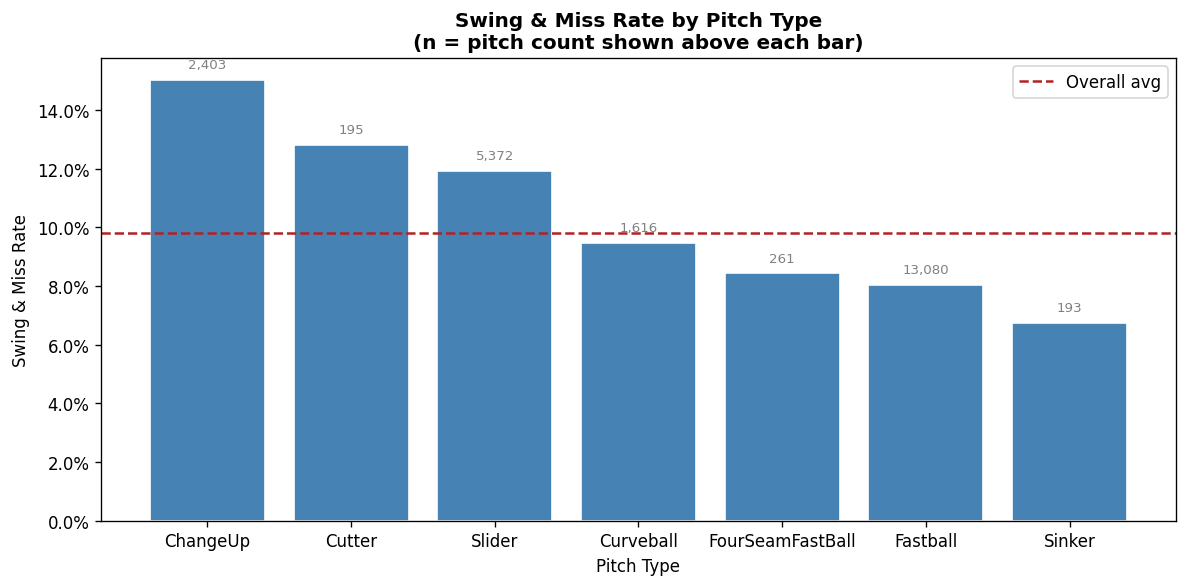

In [ ]:
pitch_swm = (
    df.groupby('TaggedPitchType')['swing_and_miss']
    .agg(['mean', 'count'])
    .rename(columns={'mean': 'SwM_Rate', 'count': 'Pitches'})
    .query('Pitches >= 50')
    .sort_values('SwM_Rate', ascending=False)
)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(pitch_swm.index, pitch_swm['SwM_Rate'], color='steelblue', edgecolor='white')
ax.axhline(df['swing_and_miss'].mean(), color='firebrick', linestyle='--', lw=1.5, label='Overall avg')

for bar, (_, row) in zip(bars, pitch_swm.iterrows()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
            f"{row['Pitches']:,.0f}", ha='center', va='bottom', fontsize=8, color='gray')

ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.set_xlabel('Pitch Type'); ax.set_ylabel('Swing & Miss Rate')
ax.set_title('Swing & Miss Rate by Pitch Type\n(n = pitch count shown above each bar)', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

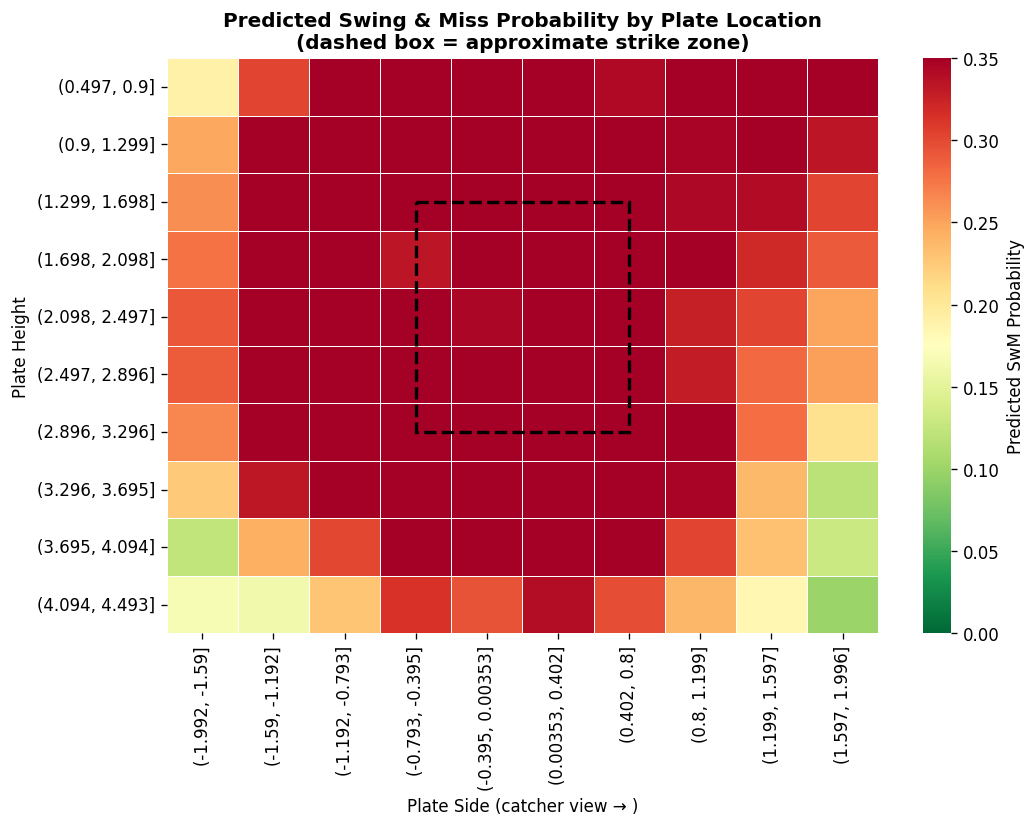

In [ ]:
# Bin plate locations and compute predicted SwM probability
X_test_copy = X_test.copy()
X_test_copy['proba'] = y_proba
X_test_copy['PlateLocSide']   = df.loc[X_test.index, 'PlateLocSide']
X_test_copy['PlateLocHeight'] = df.loc[X_test.index, 'PlateLocHeight']

# Filter to reasonable zone window
zone = X_test_copy[
    X_test_copy['PlateLocSide'].between(-2.0, 2.0) &
    X_test_copy['PlateLocHeight'].between(0.5, 4.5)
].copy()

zone['side_bin']   = pd.cut(zone['PlateLocSide'],   bins=10)
zone['height_bin'] = pd.cut(zone['PlateLocHeight'], bins=10)

heat = zone.groupby(['height_bin', 'side_bin'], observed=False)['proba'].mean().unstack()

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(heat, ax=ax, cmap='RdYlGn_r', vmin=0, vmax=0.35,
            linewidths=0.3, linecolor='white',
            cbar_kws={'label': 'Predicted SwM Probability'})

# Draw strike zone box (approximate)
ax.add_patch(plt.Rectangle((3.5, 2.5), 3, 4, fill=False, edgecolor='black', lw=2, linestyle='--'))

ax.set_xlabel('Plate Side (catcher view → )'); ax.set_ylabel('Plate Height')
ax.set_title('Predicted Swing & Miss Probability by Plate Location\n(dashed box = approximate strike zone)',
             fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
# ── Define new pitch type groups ──────────────────────────────────────────
def map_pitch_type_to_group(pitch_type):
    fastballs = ['Fastball', 'FourSeamFastBall', 'OneSeamFastBall', 'TwoSeamFastBall', 'Cutter', 'Sinker']
    breaking_balls = ['Curveball', 'Slider']
    offspeed = ['ChangeUp', 'Splitter', 'Knuckleball', 'Other'] # 'Other' assumed to be offspeed-like

    if pitch_type in fastballs:
        return 'Fastball_Group'
    elif pitch_type in breaking_balls:
        return 'BreakingBall_Group'
    elif pitch_type in offspeed:
        return 'Offspeed_Group'
    else:
        return 'Unknown_Group' # Should ideally not be hit after filtering

# ── Apply mapping and encode new group ────────────────────────────────────
df['pitch_category_group'] = df['TaggedPitchType'].apply(map_pitch_type_to_group)
le_group = LabelEncoder()
df['pitch_category_group_enc'] = le_group.fit_transform(df['pitch_category_group'])

# Add the new encoded feature to the feature matrix and list
X_stratified = X.copy()
X_stratified['pitch_category_group_enc'] = df['pitch_category_group_enc']

FINAL_FEATURES_STRATIFIED = FINAL_FEATURES + ['pitch_category_group_enc']

print('New pitch category group classes:', list(zip(le_group.classes_, le_group.transform(le_group.classes_))))
print(f"\nDistribution of new pitch groups:\n{df['pitch_category_group'].value_counts()}")
print(f'\nUpdated feature matrix shape: {X_stratified.shape}')

New pitch category group classes: [('BreakingBall_Group', np.int64(0)), ('Fastball_Group', np.int64(1)), ('Offspeed_Group', np.int64(2))]

Distribution of new pitch groups:
pitch_category_group
Fastball_Group        13749
BreakingBall_Group     6988
Offspeed_Group         2451
Name: count, dtype: int64

Updated feature matrix shape: (23188, 31)


In [ ]:
X_train_strat, X_test_strat, y_train_strat, y_test_strat = train_test_split(
    X_stratified, y, test_size=0.20, random_state=SEED,
    stratify=X_stratified['pitch_category_group_enc'] # Stratify by the new pitch group
)

print(f'Train: {X_train_strat.shape[0]:,} rows  |  Test: {X_test_strat.shape[0]:,} rows')
print(f'Train swing-and-miss rate: {y_train_strat.mean():.3f}')
print(f'Test  swing-and-miss rate: {y_test_strat.mean():.3f}')

print(f"\nTrain pitch group distribution:\n{X_train_strat['pitch_category_group_enc'].value_counts(normalize=True)}")
print(f"\nTest  pitch group distribution:\n{X_test_strat['pitch_category_group_enc'].value_counts(normalize=True)}")

Train: 18,550 rows  |  Test: 4,638 rows
Train swing-and-miss rate: 0.098
Test  swing-and-miss rate: 0.100

Train pitch group distribution:
pitch_category_group_enc
1    0.592938
0    0.301348
2    0.105714
Name: proportion, dtype: float64

Test  pitch group distribution:
pitch_category_group_enc
1    0.592928
0    0.301423
2    0.105649
Name: proportion, dtype: float64


In [ ]:
rf_strat = RandomForestClassifier(
    n_estimators=300,
    max_depth=12,
    min_samples_leaf=20,
    max_features='sqrt',
    class_weight='balanced',   # handles class imbalance (~10% positives)
    random_state=SEED,
    n_jobs=-1
)

rf_strat.fit(X_train_strat, y_train_strat)
print('Model trained with pitch type group stratification ✓')

# ── 5-fold CV AUC on training set ─────────────────────────────────────────
cv_scores_strat = cross_val_score(rf_strat, X_train_strat, y_train_strat, cv=5, scoring='roc_auc', n_jobs=-1)
print(f'\n5-Fold CV ROC-AUC: {cv_scores_strat.mean():.4f} ± {cv_scores_strat.std():.4f}')

Model trained with pitch type group stratification ✓

5-Fold CV ROC-AUC: 0.7634 ± 0.0135


In [ ]:
y_pred_strat  = rf_strat.predict(X_test_strat)
y_proba_strat = rf_strat.predict_proba(X_test_strat)[:, 1]

roc_auc_strat = roc_auc_score(y_test_strat, y_proba_strat)
avg_prec_strat = average_precision_score(y_test_strat, y_proba_strat)

print('='*50)
print(f'  ROC-AUC:             {roc_auc_strat:.4f}')
print(f'  Average Precision:   {avg_prec_strat:.4f}')
print('='*50)
print()
print(classification_report(y_test_strat, y_pred_strat, target_names=['No SwM', 'Swing & Miss']))

  ROC-AUC:             0.8222
  Average Precision:   0.3665

              precision    recall  f1-score   support

      No SwM       0.95      0.87      0.91      4174
Swing & Miss       0.34      0.58      0.42       464

    accuracy                           0.84      4638
   macro avg       0.64      0.72      0.67      4638
weighted avg       0.89      0.84      0.86      4638



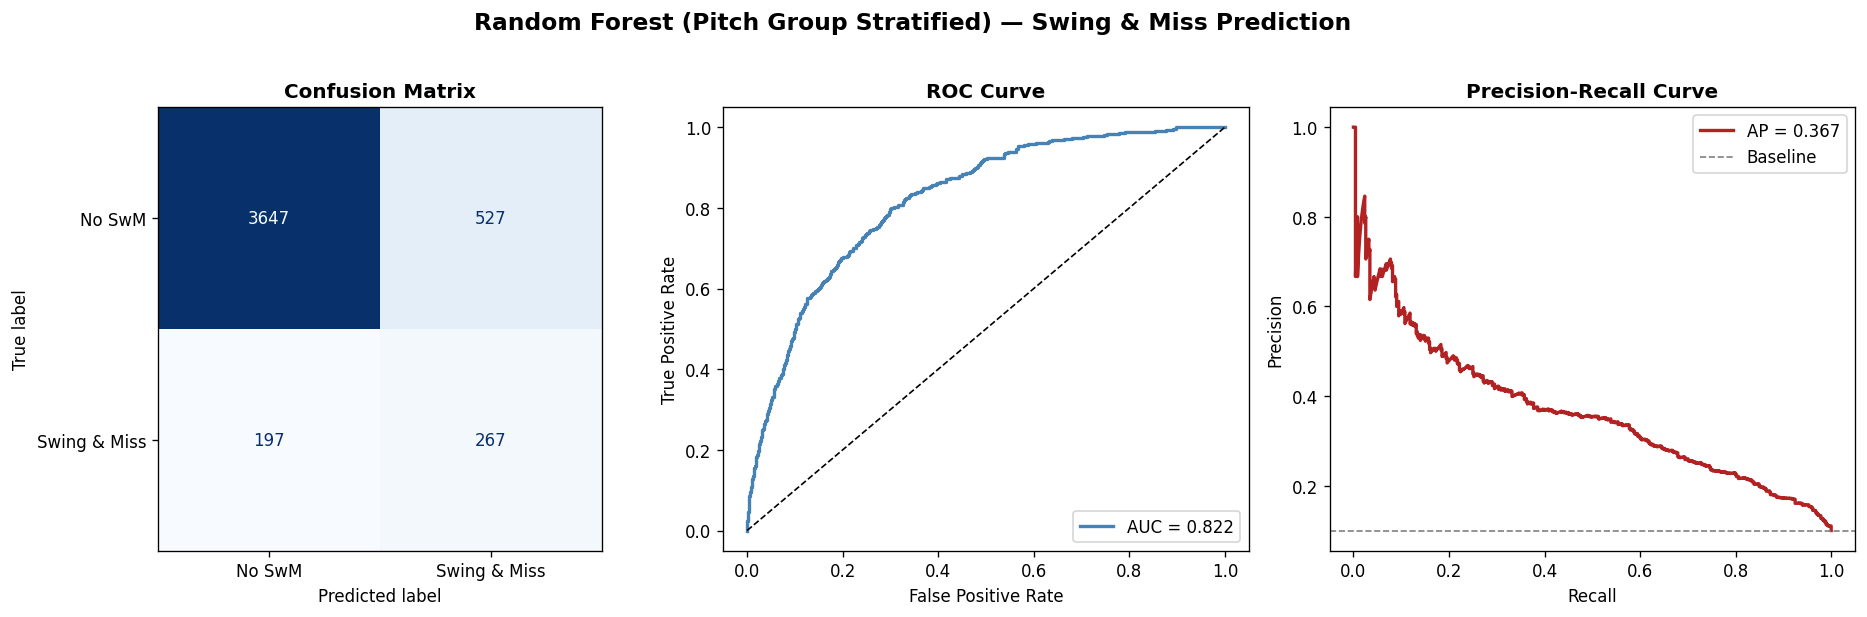

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# ── (a) Confusion Matrix ──────────────────────────────────────────────────
cm_strat = confusion_matrix(y_test_strat, y_pred_strat)
disp = ConfusionMatrixDisplay(cm_strat, display_labels=['No SwM', 'Swing & Miss'])
disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Confusion Matrix', fontweight='bold')

# ── (b) ROC Curve ─────────────────────────────────────────────────────────
fpr_strat, tpr_strat, _ = roc_curve(y_test_strat, y_proba_strat)
axes[1].plot(fpr_strat, tpr_strat, color='steelblue', lw=2, label=f'AUC = {roc_auc_strat:.3f}')
axes[1].plot([0,1],[0,1],'k--', lw=1)
axes[1].set_xlabel('False Positive Rate'); axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve', fontweight='bold')
axes[1].legend(loc='lower right')

# ── (c) Precision-Recall Curve ────────────────────────────────────────────
prec_strat, rec_strat, _ = precision_recall_curve(y_test_strat, y_proba_strat)
axes[2].plot(rec_strat, prec_strat, color='firebrick', lw=2, label=f'AP = {avg_prec_strat:.3f}')
axes[2].axhline(y_test_strat.mean(), color='gray', linestyle='--', lw=1, label='Baseline')
axes[2].set_xlabel('Recall'); axes[2].set_ylabel('Precision')
axes[2].set_title('Precision-Recall Curve', fontweight='bold')
axes[2].legend()

plt.suptitle('Random Forest (Pitch Group Stratified) — Swing & Miss Prediction', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

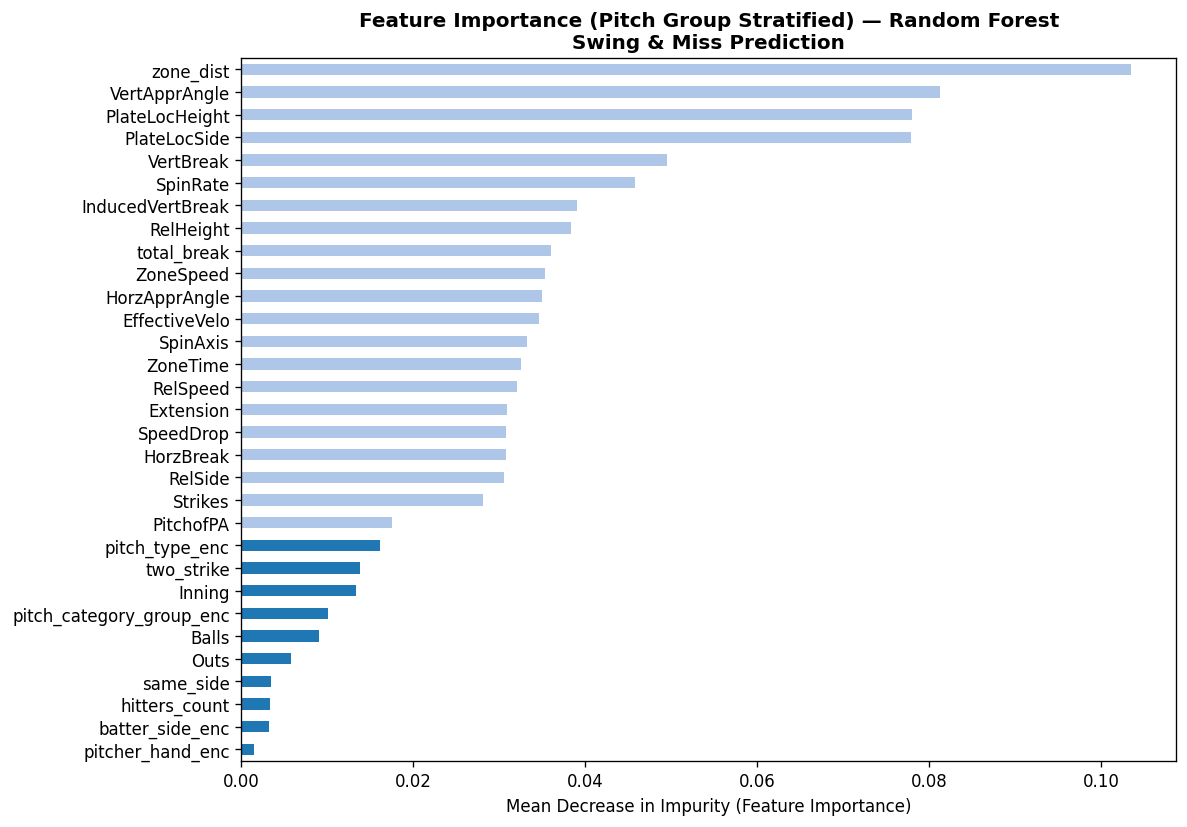

Top 10 features:
zone_dist           0.103505
VertApprAngle       0.081184
PlateLocHeight      0.077964
PlateLocSide        0.077838
VertBreak           0.049492
SpinRate            0.045816
InducedVertBreak    0.039075
RelHeight           0.038369
total_break         0.035980
ZoneSpeed           0.035291


In [ ]:
importances_strat = pd.Series(rf_strat.feature_importances_, index=FINAL_FEATURES_STRATIFIED)
importances_strat = importances_strat.sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 7))
colors = ['#1f77b4' if i < 10 else '#aec7e8' for i in range(len(importances_strat))]
importances_strat.plot(kind='barh', ax=ax, color=colors[::-1])
ax.invert_yaxis()
ax.set_xlabel('Mean Decrease in Impurity (Feature Importance)')
ax.set_title('Feature Importance (Pitch Group Stratified) — Random Forest\nSwing & Miss Prediction', fontweight='bold')
ax.axvline(0, color='black', lw=0.5)
plt.tight_layout()
plt.show()

print('Top 10 features:')
print(importances_strat.head(10).to_string())

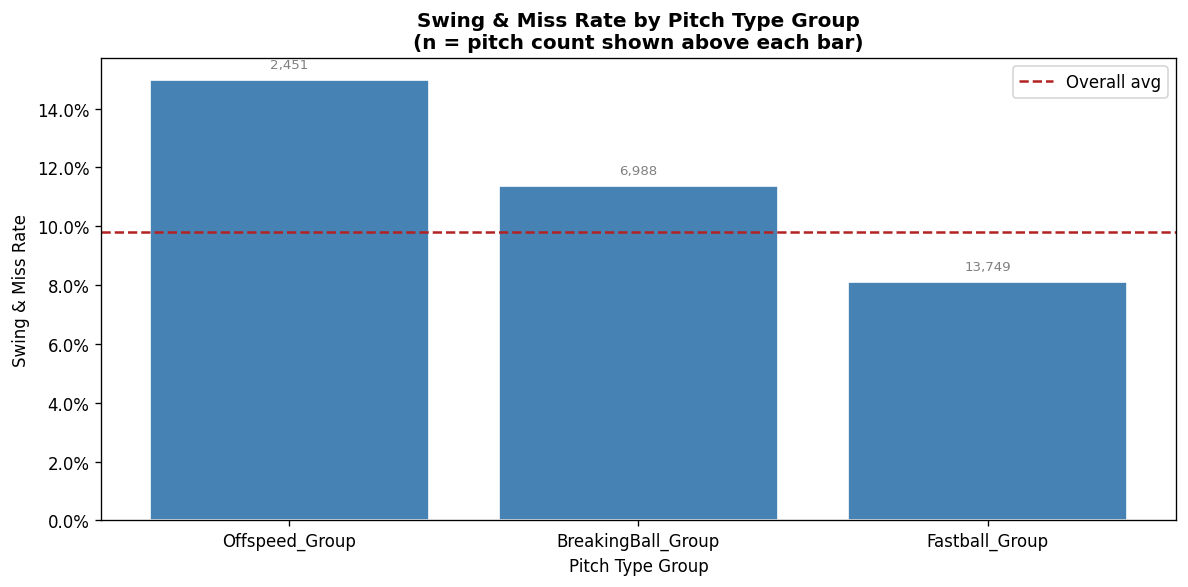

In [ ]:
pitch_swm_group = (
    df.groupby('pitch_category_group')['swing_and_miss']
    .agg(['mean', 'count'])
    .rename(columns={'mean': 'SwM_Rate', 'count': 'Pitches'})
    .query('Pitches >= 50')
    .sort_values('SwM_Rate', ascending=False)
)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(pitch_swm_group.index, pitch_swm_group['SwM_Rate'], color='steelblue', edgecolor='white')
ax.axhline(df['swing_and_miss'].mean(), color='firebrick', linestyle='--', lw=1.5, label='Overall avg')

for bar, (_, row) in zip(bars, pitch_swm_group.iterrows()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
            f"{row['Pitches']:,.0f}", ha='center', va='bottom', fontsize=8, color='gray')

ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.set_xlabel('Pitch Type Group'); ax.set_ylabel('Swing & Miss Rate')
ax.set_title('Swing & Miss Rate by Pitch Type Group\n(n = pitch count shown above each bar)', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

### 12.6 Probability Heatmap — Plate Location (with pitch type group stratification)

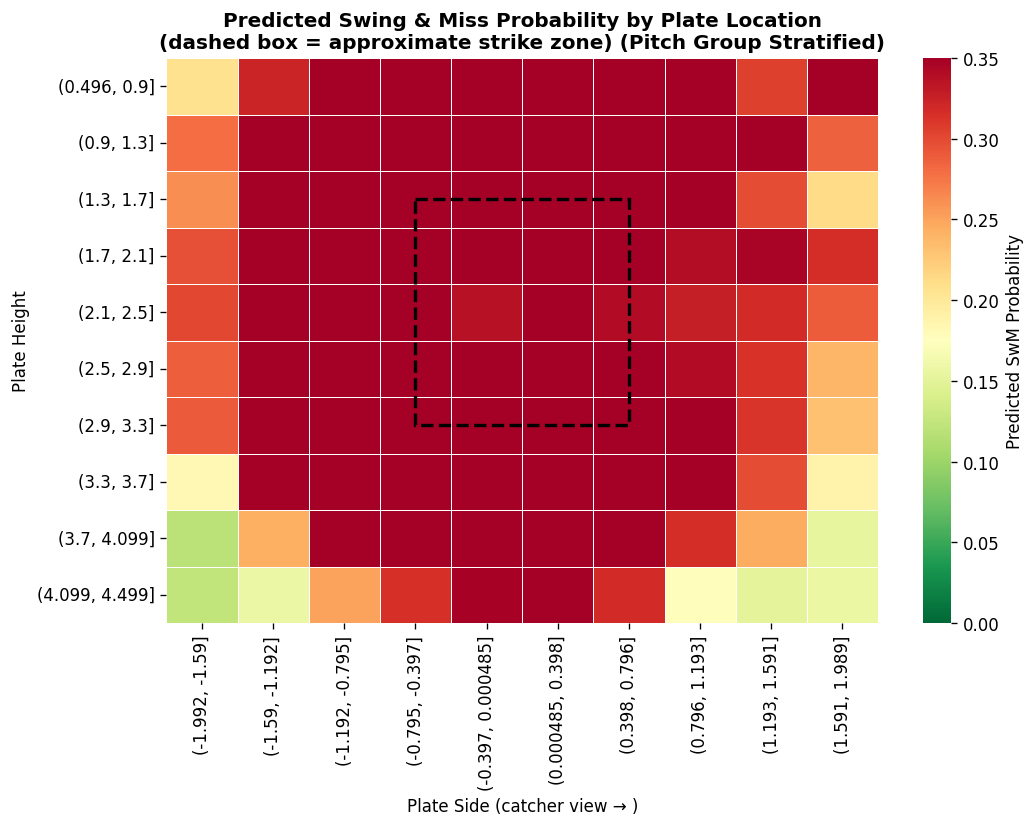

In [ ]:
# Bin plate locations and compute predicted SwM probability
X_test_copy_strat = X_test_strat.copy()
X_test_copy_strat['proba'] = y_proba_strat
X_test_copy_strat['PlateLocSide']   = df.loc[X_test_strat.index, 'PlateLocSide']
X_test_copy_strat['PlateLocHeight'] = df.loc[X_test_strat.index, 'PlateLocHeight']

# Filter to reasonable zone window
zone_strat = X_test_copy_strat[
    X_test_copy_strat['PlateLocSide'].between(-2.0, 2.0) &
    X_test_copy_strat['PlateLocHeight'].between(0.5, 4.5)
].copy()

zone_strat['side_bin']   = pd.cut(zone_strat['PlateLocSide'],   bins=10)
zone_strat['height_bin'] = pd.cut(zone_strat['PlateLocHeight'], bins=10)

heat_strat = zone_strat.groupby(['height_bin', 'side_bin'], observed=False)['proba'].mean().unstack()

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(heat_strat, ax=ax, cmap='RdYlGn_r', vmin=0, vmax=0.35,
            linewidths=0.3, linecolor='white',
            cbar_kws={'label': 'Predicted SwM Probability'})

# Draw strike zone box (approximate)
ax.add_patch(plt.Rectangle((3.5, 2.5), 3, 4, fill=False, edgecolor='black', lw=2, linestyle='--'))

ax.set_xlabel('Plate Side (catcher view → )'); ax.set_ylabel('Plate Height')
ax.set_title('Predicted Swing & Miss Probability by Plate Location\n(dashed box = approximate strike zone) (Pitch Group Stratified)',
             fontweight='bold')
plt.tight_layout()
plt.show()

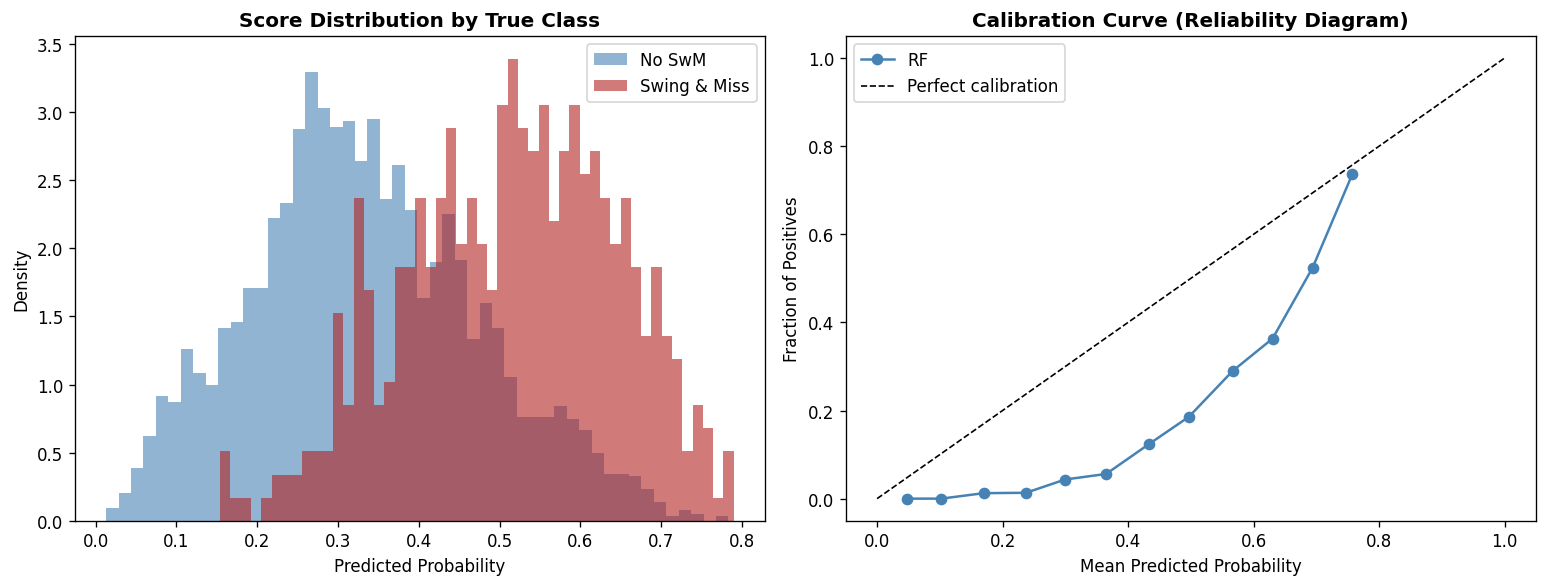

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# (a) Score distribution by true label
axes[0].hist(y_proba_strat[y_test_strat == 0], bins=50, alpha=0.6, color='steelblue', label='No SwM', density=True)
axes[0].hist(y_proba_strat[y_test_strat == 1], bins=50, alpha=0.6, color='firebrick', label='Swing & Miss', density=True)
axes[0].set_xlabel('Predicted Probability'); axes[0].set_ylabel('Density')
axes[0].set_title('Score Distribution by True Class', fontweight='bold')
axes[0].legend()

# (b) Calibration curve (reliability diagram)
from sklearn.calibration import calibration_curve
frac_pos_strat, mean_pred_strat = calibration_curve(y_test_strat, y_proba_strat, n_bins=15)
axes[1].plot(mean_pred_strat, frac_pos_strat, marker='o', color='steelblue', label='RF')
axes[1].plot([0,1],[0,1], 'k--', lw=1, label='Perfect calibration')
axes[1].set_xlabel('Mean Predicted Probability'); axes[1].set_ylabel('Fraction of Positives')
axes[1].set_title('Calibration Curve (Reliability Diagram)', fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.show()

### 12.8 Count-Specific Swing & Miss Rates vs. Model Predictions (with pitch type group stratification)

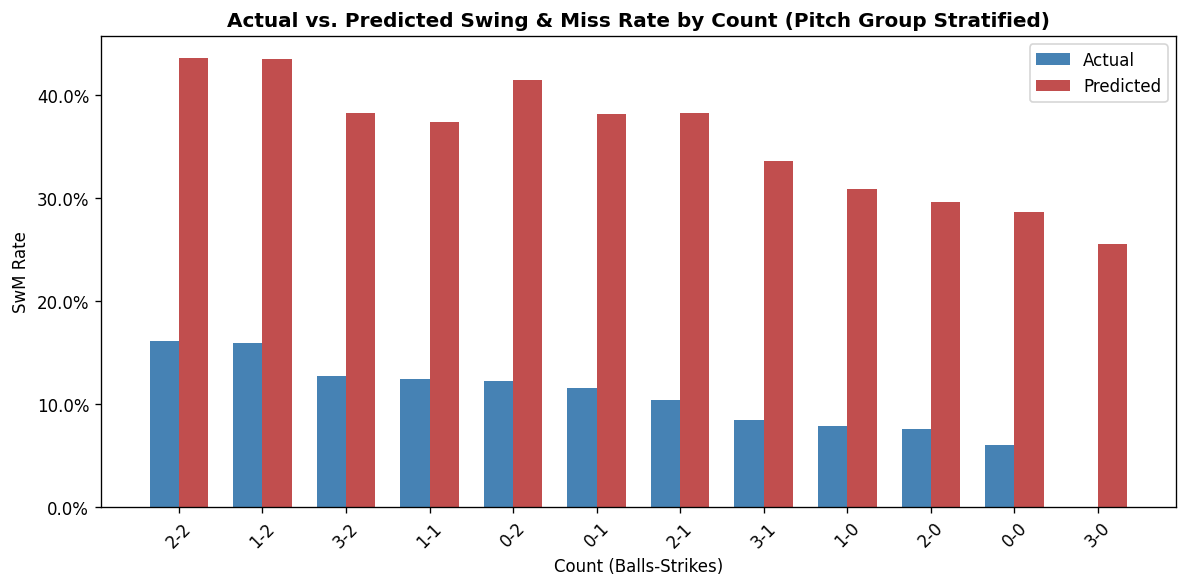

       Actual_SwM  Predicted_SwM     N
count                                 
2-2      0.161194       0.435916   335
1-2      0.159686       0.435317   382
3-2      0.127119       0.383093   236
1-1      0.124424       0.374569   434
0-2      0.122047       0.414817   254
0-1      0.115809       0.381808   544
2-1      0.103333       0.382798   300
3-1      0.083969       0.336335   131
1-0      0.078585       0.309162   509
2-0      0.076087       0.296796   184
0-0      0.059904       0.286637  1252
3-0      0.000000       0.255376    77


In [ ]:
test_df_strat = df.loc[X_test_strat.index, ['Balls', 'Strikes', 'swing_and_miss']].copy()
test_df_strat['proba'] = y_proba_strat
test_df_strat['count'] = test_df_strat['Balls'].astype(int).astype(str) + '-' + test_df_strat['Strikes'].astype(int).astype(str)

count_summary_strat = test_df_strat.groupby('count').agg(
    Actual_SwM=('swing_and_miss', 'mean'),
    Predicted_SwM=('proba', 'mean'),
    N=('swing_and_miss', 'count')
).query('N >= 30').sort_values('Actual_SwM', ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(count_summary_strat))
w = 0.35
ax.bar(x - w/2, count_summary_strat['Actual_SwM'],    w, label='Actual',    color='steelblue')
ax.bar(x + w/2, count_summary_strat['Predicted_SwM'], w, label='Predicted', color='firebrick', alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels(count_summary_strat.index, rotation=45)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.set_title('Actual vs. Predicted Swing & Miss Rate by Count (Pitch Group Stratified)', fontweight='bold')
ax.set_xlabel('Count (Balls-Strikes)'); ax.set_ylabel('SwM Rate')
ax.legend()
plt.tight_layout()
plt.show()

print(count_summary_strat.to_string())

In [ ]:
print('='*55)
print('   RANDOM FOREST — SWING & MISS PREDICTION SUMMARY (PITCH GROUP STRATIFIED)')
print('='*55)
print(f'  Training samples :  {X_train_strat.shape[0]:,}')
print(f'  Test samples     :  {X_test_strat.shape[0]:,}')
print(f'  # Features       :  {X_stratified.shape[1]}')
print(f'  Estimators       :  {rf_strat.n_estimators}')
print(f'  Max depth        :  {rf_strat.max_depth}')
print(f'  Class weighting  :  balanced')
print('-'*55)
print(f'  5-Fold CV AUC    :  {cv_scores_strat.mean():.4f} ± {cv_scores_strat.std():.4f}')
print(f'  Test ROC-AUC     :  {roc_auc_strat:.4f}')
print(f'  Test Avg Prec    :  {avg_prec_strat:.4f}')
print('='*55)
print('\nTop 5 predictive features:')
for i, (feat, imp) in enumerate(importances_strat.head(5).items(), 1):
    print(f'  {i}. {feat:<25} {imp:.4f}')

   RANDOM FOREST — SWING & MISS PREDICTION SUMMARY (PITCH GROUP STRATIFIED)
  Training samples :  18,550
  Test samples     :  4,638
  # Features       :  31
  Estimators       :  300
  Max depth        :  12
  Class weighting  :  balanced
-------------------------------------------------------
  5-Fold CV AUC    :  0.7634 ± 0.0135
  Test ROC-AUC     :  0.8222
  Test Avg Prec    :  0.3665

Top 5 predictive features:
  1. zone_dist                 0.1035
  2. VertApprAngle             0.0812
  3. PlateLocHeight            0.0780
  4. PlateLocSide              0.0778
  5. VertBreak                 0.0495


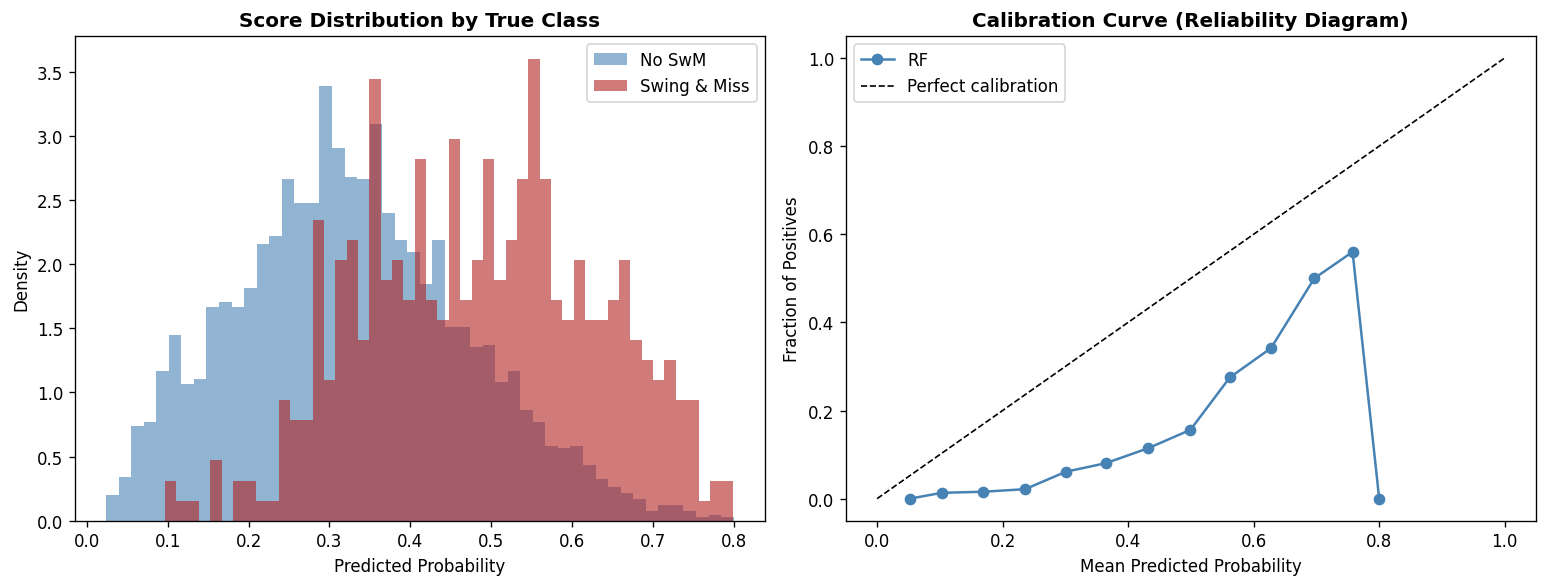

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# (a) Score distribution by true label
axes[0].hist(y_proba[y_test == 0], bins=50, alpha=0.6, color='steelblue', label='No SwM', density=True)
axes[0].hist(y_proba[y_test == 1], bins=50, alpha=0.6, color='firebrick', label='Swing & Miss', density=True)
axes[0].set_xlabel('Predicted Probability'); axes[0].set_ylabel('Density')
axes[0].set_title('Score Distribution by True Class', fontweight='bold')
axes[0].legend()

# (b) Calibration curve (reliability diagram)
from sklearn.calibration import calibration_curve
frac_pos, mean_pred = calibration_curve(y_test, y_proba, n_bins=15)
axes[1].plot(mean_pred, frac_pos, marker='o', color='steelblue', label='RF')
axes[1].plot([0,1],[0,1], 'k--', lw=1, label='Perfect calibration')
axes[1].set_xlabel('Mean Predicted Probability'); axes[1].set_ylabel('Fraction of Positives')
axes[1].set_title('Calibration Curve (Reliability Diagram)', fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.show()

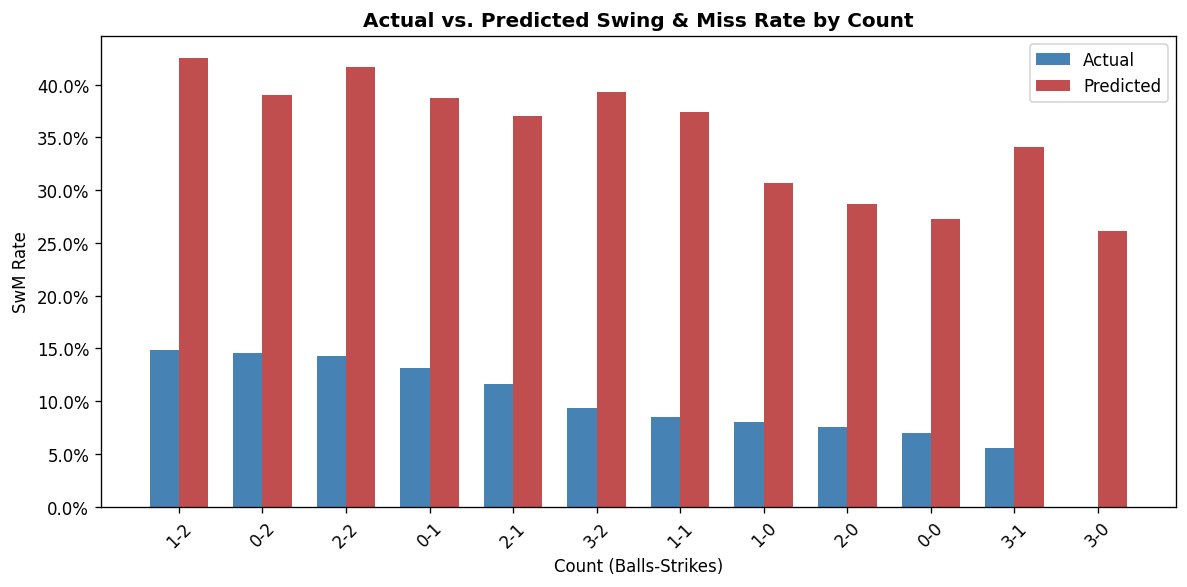

       Actual_SwM  Predicted_SwM     N
count                                 
1-2      0.148438       0.424895   384
0-2      0.145907       0.390181   281
2-2      0.143322       0.416498   307
0-1      0.131679       0.387247   524
2-1      0.116667       0.370112   240
3-2      0.093220       0.392664   236
1-1      0.085437       0.373843   515
1-0      0.080306       0.306608   523
2-0      0.075377       0.286452   199
0-0      0.069749       0.272501  1233
3-1      0.055556       0.341138   126
3-0      0.000000       0.261156    70


In [ ]:
test_df = df.loc[X_test.index, ['Balls', 'Strikes', 'swing_and_miss']].copy()
test_df['proba'] = y_proba
test_df['count'] = test_df['Balls'].astype(int).astype(str) + '-' + test_df['Strikes'].astype(int).astype(str)

count_summary = test_df.groupby('count').agg(
    Actual_SwM=('swing_and_miss', 'mean'),
    Predicted_SwM=('proba', 'mean'),
    N=('swing_and_miss', 'count')
).query('N >= 30').sort_values('Actual_SwM', ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(count_summary))
w = 0.35
ax.bar(x - w/2, count_summary['Actual_SwM'],    w, label='Actual',    color='steelblue')
ax.bar(x + w/2, count_summary['Predicted_SwM'], w, label='Predicted', color='firebrick', alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels(count_summary.index, rotation=45)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.set_title('Actual vs. Predicted Swing & Miss Rate by Count', fontweight='bold')
ax.set_xlabel('Count (Balls-Strikes)'); ax.set_ylabel('SwM Rate')
ax.legend()
plt.tight_layout()
plt.show()

print(count_summary.to_string())

In [ ]:
import tensorflow as tf
from tensorflow import keras
from sklearn.preprocessing import StandardScaler

print('TensorFlow imported ✓')

# Scale features (important for neural networks)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_strat)
X_test_scaled = scaler.transform(X_test_strat)

print('Features scaled ✓')

TensorFlow imported ✓
Features scaled ✓


Neural Network model trained ✓


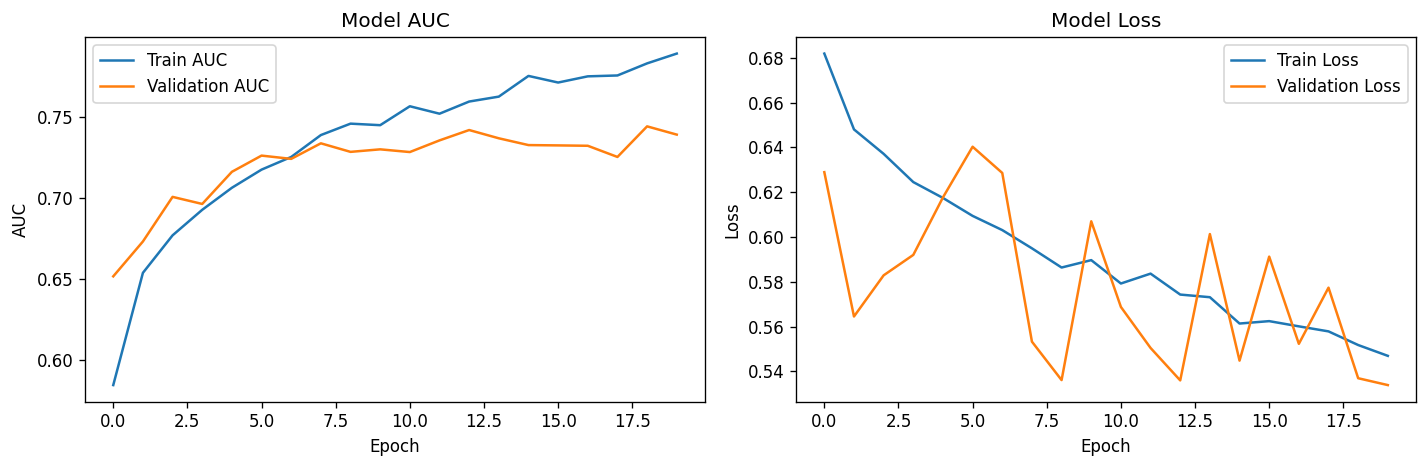

In [ ]:
model = keras.Sequential([
    keras.layers.Dense(128, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(64, activation='relu'),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(32, activation='relu'),
    keras.layers.Dense(1, activation='sigmoid') # Output layer for binary classification
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=[tf.keras.metrics.AUC(name='auc'), 'accuracy']
)

# Use class weights to handle imbalance, similar to RandomForest
neg, pos = np.bincount(y_train_strat)
total = neg + pos
weight_for_0 = (1 / neg) * (total / 2.0)
weight_for_1 = (1 / pos) * (total / 2.0)
class_weight = {0: weight_for_0, 1: weight_for_1}

history = model.fit(
    X_train_scaled, y_train_strat,
    epochs=20,
    batch_size=32,
    validation_split=0.2,
    class_weight=class_weight,
    verbose=0
)

print('Neural Network model trained ✓')

# Plot training history
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(history.history['auc'], label='Train AUC')
ax1.plot(history.history['val_auc'], label='Validation AUC')
ax1.set_title('Model AUC')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('AUC')
ax1.legend()

ax2.plot(history.history['loss'], label='Train Loss')
ax2.plot(history.history['val_loss'], label='Validation Loss')
ax2.set_title('Model Loss')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()

plt.tight_layout()
plt.show()

### 13.2 Evaluate Neural Network on Test Set

In [ ]:
y_pred_nn_proba = model.predict(X_test_scaled).flatten()
y_pred_nn = (y_pred_nn_proba > 0.5).astype(int)

roc_auc_nn = roc_auc_score(y_test_strat, y_pred_nn_proba)
avg_prec_nn = average_precision_score(y_test_strat, y_pred_nn_proba)

print('='*50)
print(f'  NN ROC-AUC:             {roc_auc_nn:.4f}')
print(f'  NN Average Precision:   {avg_prec_nn:.4f}')
print('='*50)
print()
print(classification_report(y_test_strat, y_pred_nn, target_names=['No SwM', 'Swing & Miss']))

145/145 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
  NN ROC-AUC:             0.7766
  NN Average Precision:   0.2747

              precision    recall  f1-score   support

      No SwM       0.95      0.70      0.81      4174
Swing & Miss       0.21      0.70      0.32       464

    accuracy                           0.70      4638
   macro avg       0.58      0.70      0.56      4638
weighted avg       0.88      0.70      0.76      4638



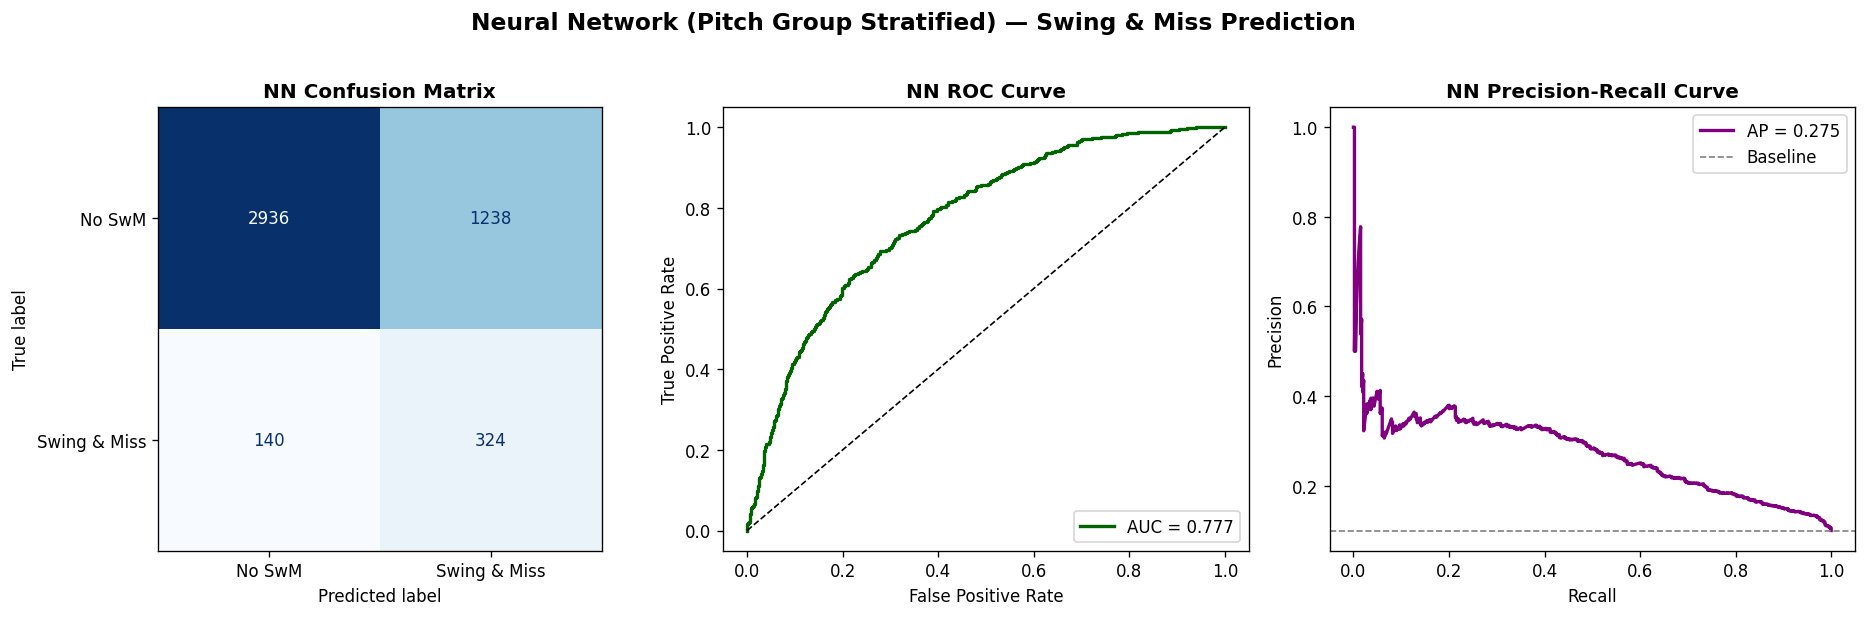

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# ── (a) Confusion Matrix ──────────────────────────────────────────────────
cm_nn = confusion_matrix(y_test_strat, y_pred_nn)
disp = ConfusionMatrixDisplay(cm_nn, display_labels=['No SwM', 'Swing & Miss'])
disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('NN Confusion Matrix', fontweight='bold')

# ── (b) ROC Curve ─────────────────────────────────────────────────────────
fpr_nn, tpr_nn, _ = roc_curve(y_test_strat, y_pred_nn_proba)
axes[1].plot(fpr_nn, tpr_nn, color='darkgreen', lw=2, label=f'AUC = {roc_auc_nn:.3f}')
axes[1].plot([0,1],[0,1],'k--', lw=1)
axes[1].set_xlabel('False Positive Rate'); axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('NN ROC Curve', fontweight='bold')
axes[1].legend(loc='lower right')

# ── (c) Precision-Recall Curve ────────────────────────────────────────────
prec_nn, rec_nn, _ = precision_recall_curve(y_test_strat, y_pred_nn_proba)
axes[2].plot(rec_nn, prec_nn, color='purple', lw=2, label=f'AP = {avg_prec_nn:.3f}')
axes[2].axhline(y_test_strat.mean(), color='gray', linestyle='--', lw=1, label='Baseline')
axes[2].set_xlabel('Recall'); axes[2].set_ylabel('Precision')
axes[2].set_title('NN Precision-Recall Curve', fontweight='bold')
axes[2].legend()

plt.suptitle('Neural Network (Pitch Group Stratified) — Swing & Miss Prediction', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### 13.3 Probability Distribution — Calibration Check (Neural Network)

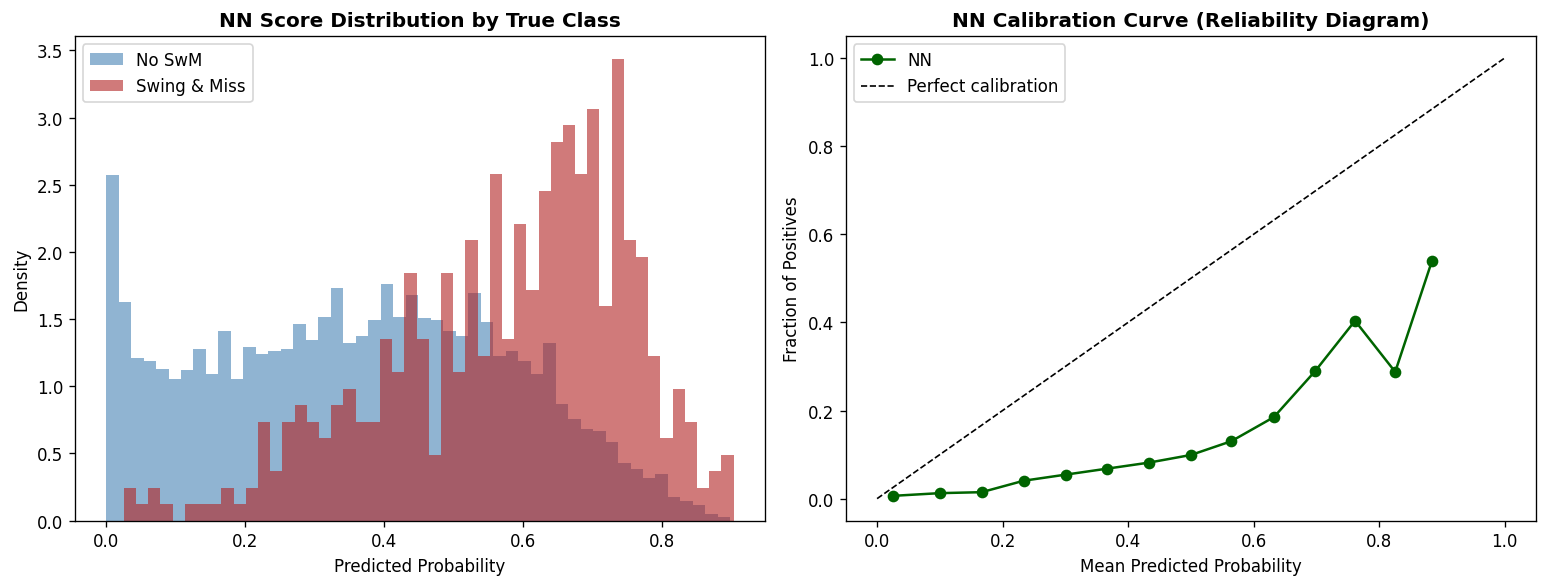

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# (a) Score distribution by true label
axes[0].hist(y_pred_nn_proba[y_test_strat == 0], bins=50, alpha=0.6, color='steelblue', label='No SwM', density=True)
axes[0].hist(y_pred_nn_proba[y_test_strat == 1], bins=50, alpha=0.6, color='firebrick', label='Swing & Miss', density=True)
axes[0].set_xlabel('Predicted Probability'); axes[0].set_ylabel('Density')
axes[0].set_title('NN Score Distribution by True Class', fontweight='bold')
axes[0].legend()

# (b) Calibration curve (reliability diagram)
frac_pos_nn, mean_pred_nn = calibration_curve(y_test_strat, y_pred_nn_proba, n_bins=15)
axes[1].plot(mean_pred_nn, frac_pos_nn, marker='o', color='darkgreen', label='NN')
axes[1].plot([0,1],[0,1], 'k--', lw=1, label='Perfect calibration')
axes[1].set_xlabel('Mean Predicted Probability'); axes[1].set_ylabel('Fraction of Positives')
axes[1].set_title('NN Calibration Curve (Reliability Diagram)', fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.show()

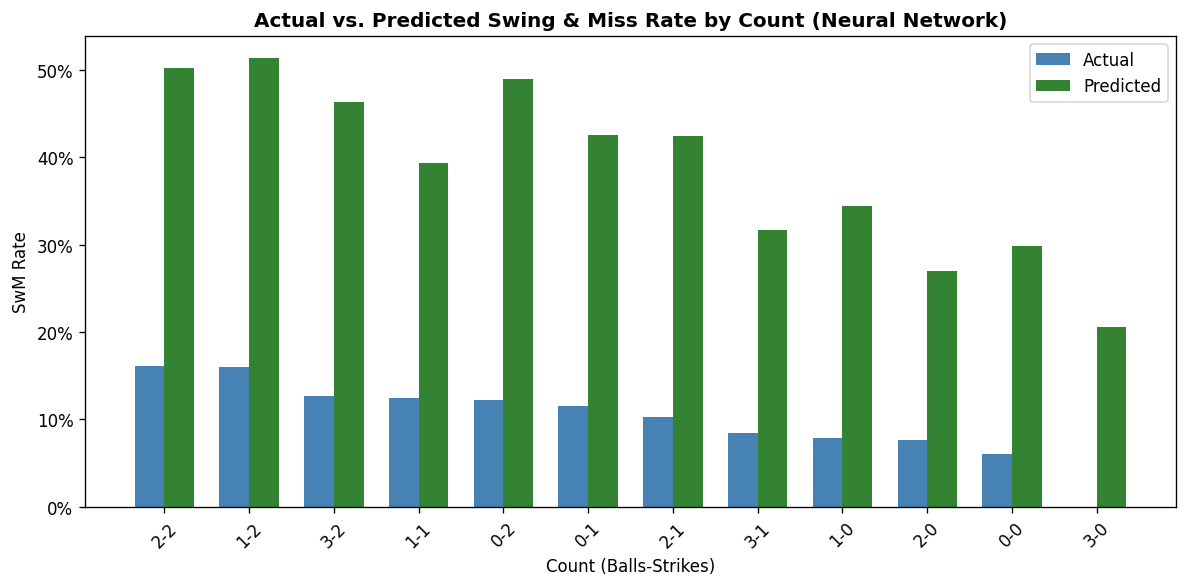

       Actual_SwM  Predicted_SwM     N
count                                 
2-2      0.161194       0.502502   335
1-2      0.159686       0.513360   382
3-2      0.127119       0.463900   236
1-1      0.124424       0.393586   434
0-2      0.122047       0.490331   254
0-1      0.115809       0.425140   544
2-1      0.103333       0.425038   300
3-1      0.083969       0.316582   131
1-0      0.078585       0.344518   509
2-0      0.076087       0.270459   184
0-0      0.059904       0.298308  1252
3-0      0.000000       0.205929    77


In [ ]:
test_df_nn = df.loc[X_test_strat.index, ['Balls', 'Strikes', 'swing_and_miss']].copy()
test_df_nn['proba'] = y_pred_nn_proba
test_df_nn['count'] = test_df_nn['Balls'].astype(int).astype(str) + '-' + test_df_nn['Strikes'].astype(int).astype(str)

count_summary_nn = test_df_nn.groupby('count').agg(
    Actual_SwM=('swing_and_miss', 'mean'),
    Predicted_SwM=('proba', 'mean'),
    N=('swing_and_miss', 'count')
).query('N >= 30').sort_values('Actual_SwM', ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(count_summary_nn))
w = 0.35
ax.bar(x - w/2, count_summary_nn['Actual_SwM'],    w, label='Actual',    color='steelblue')
ax.bar(x + w/2, count_summary_nn['Predicted_SwM'], w, label='Predicted', color='darkgreen', alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels(count_summary_nn.index, rotation=45)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.set_title('Actual vs. Predicted Swing & Miss Rate by Count (Neural Network)', fontweight='bold')
ax.set_xlabel('Count (Balls-Strikes)'); ax.set_ylabel('SwM Rate')
ax.legend()
plt.tight_layout()
plt.show()

print(count_summary_nn.to_string())

In [ ]:
print('='*55)
print('   NEURAL NETWORK — SWING & MISS PREDICTION SUMMARY (PITCH GROUP STRATIFIED)')
print('='*55)
print(f'  Training samples :  {X_train_strat.shape[0]:,}')
print(f'  Test samples     :  {X_test_strat.shape[0]:,}')
print(f'  # Features       :  {X_stratified.shape[1]}')
print(f'  Epochs           :  {len(history.history["loss"])}')
print(f'  Class weighting  :  balanced')
print('-'*55)
print(f'  Test ROC-AUC     :  {roc_auc_nn:.4f}')
print(f'  Test Avg Prec    :  {avg_prec_nn:.4f}')
print('='*55)

   NEURAL NETWORK — SWING & MISS PREDICTION SUMMARY (PITCH GROUP STRATIFIED)
  Training samples :  18,550
  Test samples     :  4,638
  # Features       :  31
  Epochs           :  20
  Class weighting  :  balanced
-------------------------------------------------------
  Test ROC-AUC     :  0.7766
  Test Avg Prec    :  0.2747


In [ ]:
from sklearn.linear_model import LogisticRegression

# Initialize and train the Logistic Regression model
lr = LogisticRegression(
    solver='liblinear', # Good for small datasets and 'balanced' class_weight
    class_weight='balanced', # Handles class imbalance
    random_state=SEED,
    n_jobs=-1
)

lr.fit(X_train_scaled, y_train_strat)
print('Logistic Regression model trained ✓')

# ── 5-fold CV AUC on training set ─────────────────────────────────────────
cv_scores_lr = cross_val_score(lr, X_train_scaled, y_train_strat, cv=5, scoring='roc_auc', n_jobs=-1)
print(f'\n5-Fold CV ROC-AUC: {cv_scores_lr.mean():.4f} ± {cv_scores_lr.std():.4f}')

Logistic Regression model trained ✓

5-Fold CV ROC-AUC: 0.6172 ± 0.0032


In [ ]:
y_pred_lr_proba = lr.predict_proba(X_test_scaled)[:, 1]
y_pred_lr = (y_pred_lr_proba > 0.5).astype(int)

roc_auc_lr = roc_auc_score(y_test_strat, y_pred_lr_proba)
avg_prec_lr = average_precision_score(y_test_strat, y_pred_lr_proba)

print('='*50)
print(f'  LR ROC-AUC:             {roc_auc_lr:.4f}')
print(f'  LR Average Precision:   {avg_prec_lr:.4f}')
print('='*50)
print()
print(classification_report(y_test_strat, y_pred_lr, target_names=['No SwM', 'Swing & Miss']))

  LR ROC-AUC:             0.6339
  LR Average Precision:   0.1406

              precision    recall  f1-score   support

      No SwM       0.93      0.58      0.72      4174
Swing & Miss       0.14      0.61      0.23       464

    accuracy                           0.59      4638
   macro avg       0.53      0.59      0.47      4638
weighted avg       0.85      0.59      0.67      4638



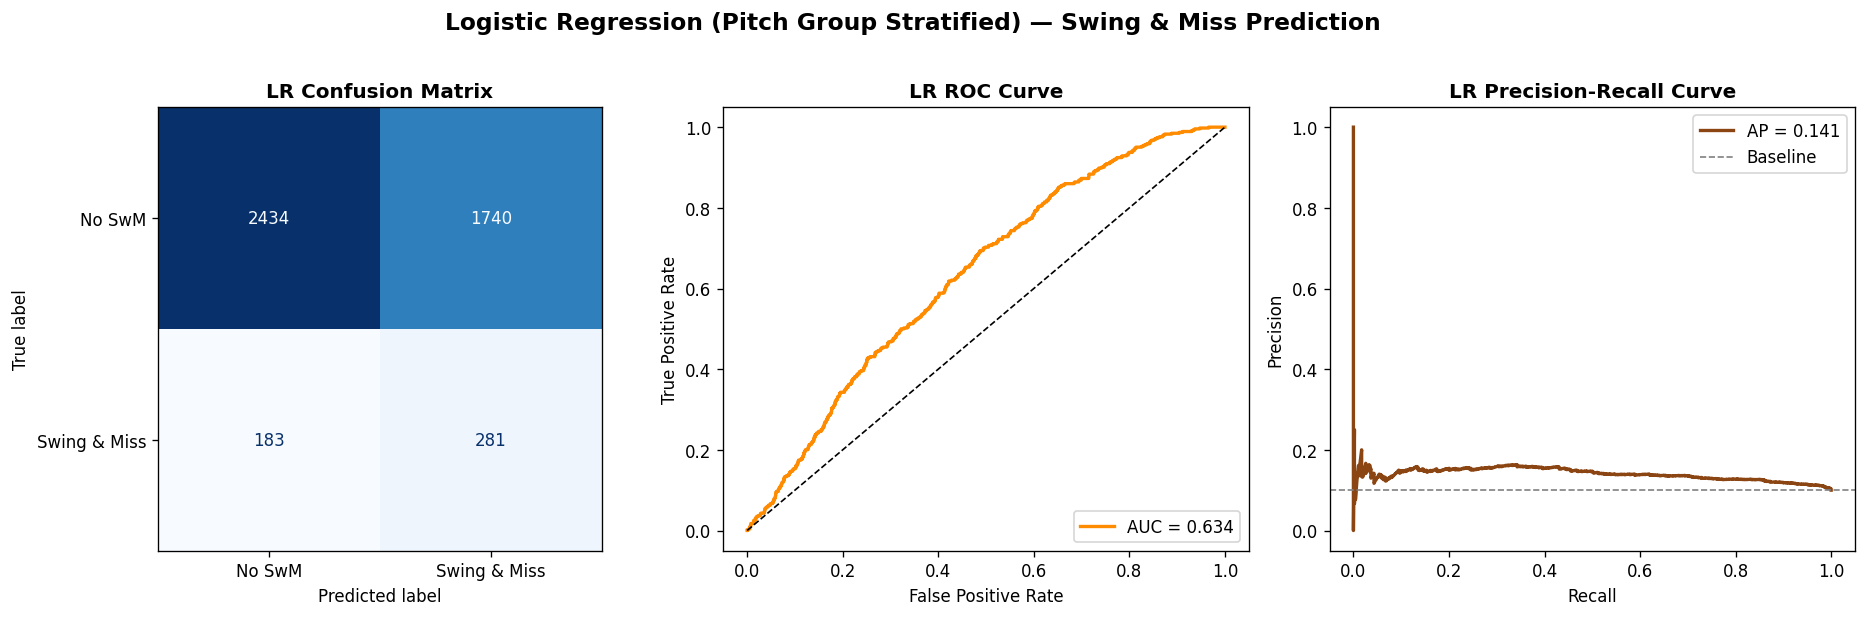

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# ── (a) Confusion Matrix ──────────────────────────────────────────────────
cm_lr = confusion_matrix(y_test_strat, y_pred_lr)
disp = ConfusionMatrixDisplay(cm_lr, display_labels=['No SwM', 'Swing & Miss'])
disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('LR Confusion Matrix', fontweight='bold')

# ── (b) ROC Curve ─────────────────────────────────────────────────────────
fpr_lr, tpr_lr, _ = roc_curve(y_test_strat, y_pred_lr_proba)
axes[1].plot(fpr_lr, tpr_lr, color='darkorange', lw=2, label=f'AUC = {roc_auc_lr:.3f}')
axes[1].plot([0,1],[0,1],'k--', lw=1)
axes[1].set_xlabel('False Positive Rate'); axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('LR ROC Curve', fontweight='bold')
axes[1].legend(loc='lower right')

# ── (c) Precision-Recall Curve ────────────────────────────────────────────
prec_lr, rec_lr, _ = precision_recall_curve(y_test_strat, y_pred_lr_proba)
axes[2].plot(rec_lr, prec_lr, color='saddlebrown', lw=2, label=f'AP = {avg_prec_lr:.3f}')
axes[2].axhline(y_test_strat.mean(), color='gray', linestyle='--', lw=1, label='Baseline')
axes[2].set_xlabel('Recall'); axes[2].set_ylabel('Precision')
axes[2].set_title('LR Precision-Recall Curve', fontweight='bold')
axes[2].legend()

plt.suptitle('Logistic Regression (Pitch Group Stratified) — Swing & Miss Prediction', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

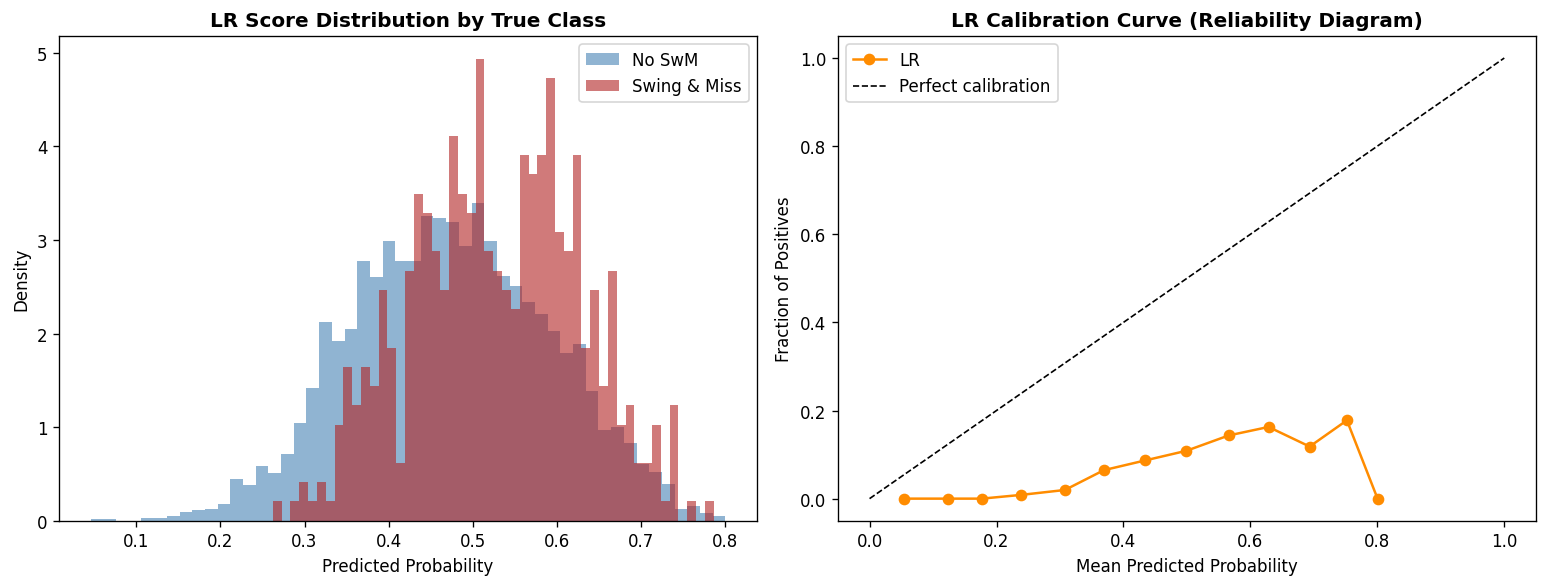

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# (a) Score distribution by true label
axes[0].hist(y_pred_lr_proba[y_test_strat == 0], bins=50, alpha=0.6, color='steelblue', label='No SwM', density=True)
axes[0].hist(y_pred_lr_proba[y_test_strat == 1], bins=50, alpha=0.6, color='firebrick', label='Swing & Miss', density=True)
axes[0].set_xlabel('Predicted Probability'); axes[0].set_ylabel('Density')
axes[0].set_title('LR Score Distribution by True Class', fontweight='bold')
axes[0].legend()

# (b) Calibration curve (reliability diagram)
frac_pos_lr, mean_pred_lr = calibration_curve(y_test_strat, y_pred_lr_proba, n_bins=15)
axes[1].plot(mean_pred_lr, frac_pos_lr, marker='o', color='darkorange', label='LR')
axes[1].plot([0,1],[0,1], 'k--', lw=1, label='Perfect calibration')
axes[1].set_xlabel('Mean Predicted Probability'); axes[1].set_ylabel('Fraction of Positives')
axes[1].set_title('LR Calibration Curve (Reliability Diagram)', fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.show()

### 14.3 Count-Specific Swing & Miss Rates vs. Model Predictions (Logistic Regression)

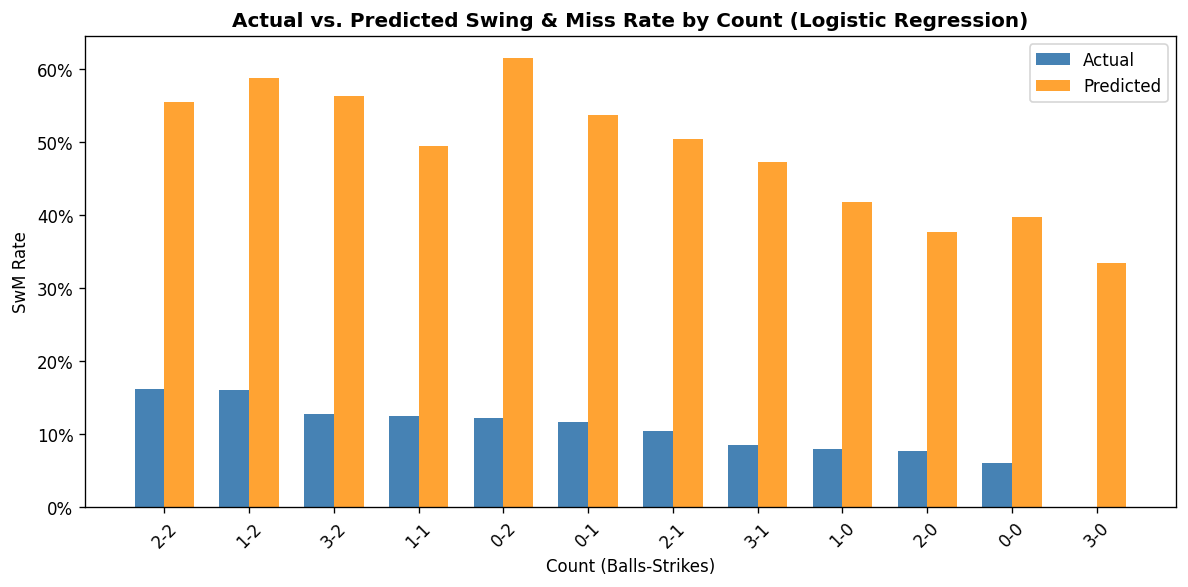

       Actual_SwM  Predicted_SwM     N
count                                 
2-2      0.161194       0.553953   335
1-2      0.159686       0.586737   382
3-2      0.127119       0.562889   236
1-1      0.124424       0.494153   434
0-2      0.122047       0.614158   254
0-1      0.115809       0.537007   544
2-1      0.103333       0.504059   300
3-1      0.083969       0.472307   131
1-0      0.078585       0.417421   509
2-0      0.076087       0.375746   184
0-0      0.059904       0.397403  1252
3-0      0.000000       0.334543    77


In [ ]:
test_df_lr = df.loc[X_test_strat.index, ['Balls', 'Strikes', 'swing_and_miss']].copy()
test_df_lr['proba'] = y_pred_lr_proba
test_df_lr['count'] = test_df_lr['Balls'].astype(int).astype(str) + '-' + test_df_lr['Strikes'].astype(int).astype(str)

count_summary_lr = test_df_lr.groupby('count').agg(
    Actual_SwM=('swing_and_miss', 'mean'),
    Predicted_SwM=('proba', 'mean'),
    N=('swing_and_miss', 'count')
).query('N >= 30').sort_values('Actual_SwM', ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(count_summary_lr))
w = 0.35
ax.bar(x - w/2, count_summary_lr['Actual_SwM'],    w, label='Actual',    color='steelblue')
ax.bar(x + w/2, count_summary_lr['Predicted_SwM'], w, label='Predicted', color='darkorange', alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels(count_summary_lr.index, rotation=45)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.set_title('Actual vs. Predicted Swing & Miss Rate by Count (Logistic Regression)', fontweight='bold')
ax.set_xlabel('Count (Balls-Strikes)'); ax.set_ylabel('SwM Rate')
ax.legend()
plt.tight_layout()
plt.show()

print(count_summary_lr.to_string())

In [ ]:
print('='*55)
print('   LOGISTIC REGRESSION — SWING & MISS PREDICTION SUMMARY (PITCH GROUP STRATIFIED)')
print('='*55)
print(f'  Training samples :  {X_train_strat.shape[0]:,}')
print(f'  Test samples     :  {X_test_strat.shape[0]:,}')
print(f'  # Features       :  {X_stratified.shape[1]}')
print(f'  Class weighting  :  balanced')
print('-'*55)
print(f'  5-Fold CV AUC    :  {cv_scores_lr.mean():.4f} ± {cv_scores_lr.std():.4f}')
print(f'  Test ROC-AUC     :  {roc_auc_lr:.4f}')
print(f'  Test Avg Prec    :  {avg_prec_lr:.4f}')
print('='*55)

   LOGISTIC REGRESSION — SWING & MISS PREDICTION SUMMARY (PITCH GROUP STRATIFIED)
  Training samples :  18,550
  Test samples     :  4,638
  # Features       :  31
  Class weighting  :  balanced
-------------------------------------------------------
  5-Fold CV AUC    :  0.6172 ± 0.0032
  Test ROC-AUC     :  0.6339
  Test Avg Prec    :  0.1406


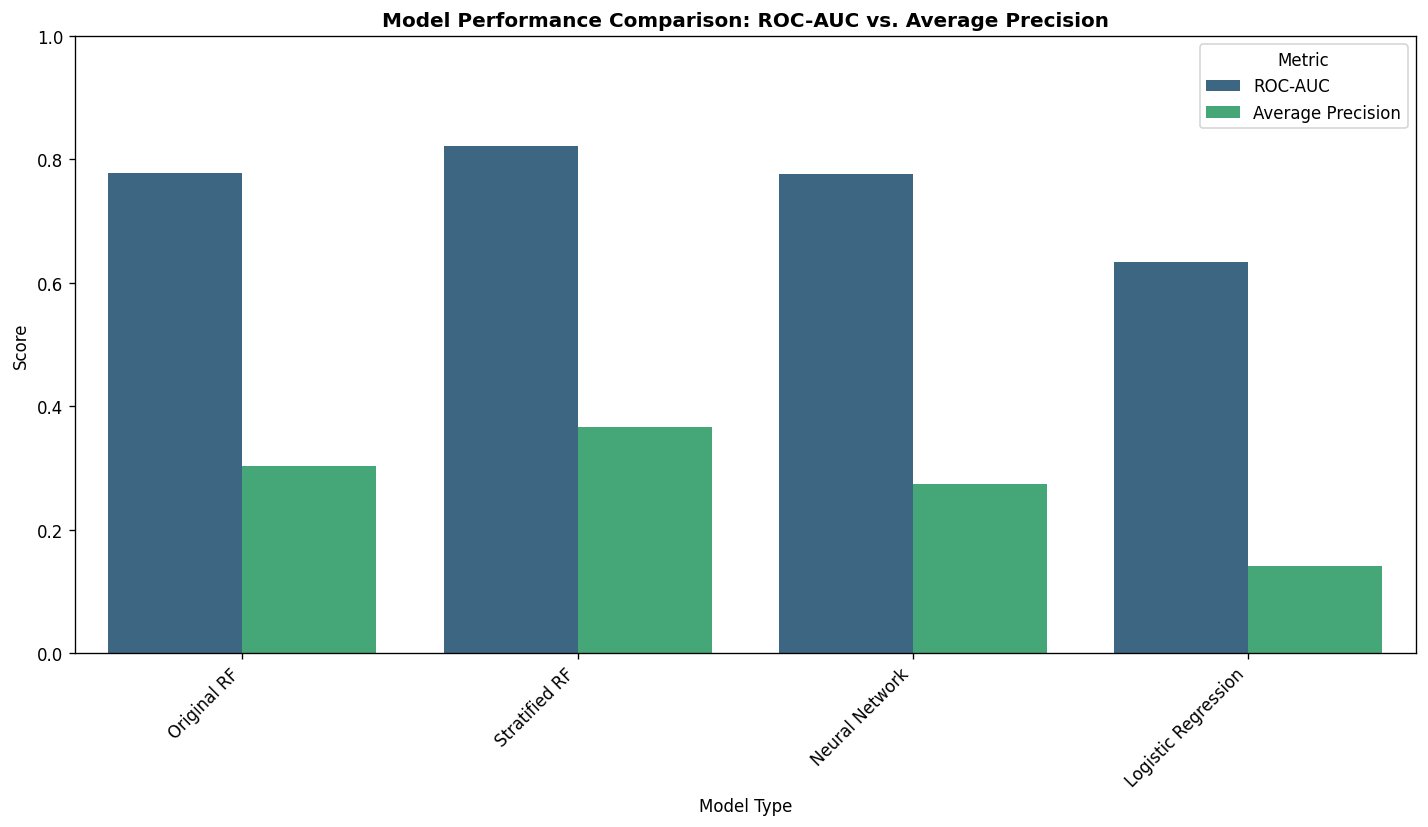

In [ ]:
model_comparison_data = {
    'Model': [
        'Original RF',
        'Stratified RF',
        'Neural Network',
        'Logistic Regression'
    ],
    'ROC-AUC': [
        roc_auc,
        roc_auc_strat,
        roc_auc_nn,
        roc_auc_lr
    ],
    'Average Precision': [
        avg_prec,
        avg_prec_strat,
        avg_prec_nn,
        avg_prec_lr
    ]
}

model_comparison_df = pd.DataFrame(model_comparison_data)

# Melt the DataFrame for easier plotting with seaborn
model_comparison_melted = model_comparison_df.melt(id_vars='Model', var_name='Metric', value_name='Score')

fig, ax = plt.subplots(figsize=(12, 7))
sns.barplot(x='Model', y='Score', hue='Metric', data=model_comparison_melted, palette='viridis', ax=ax)

ax.set_title('Model Performance Comparison: ROC-AUC vs. Average Precision', fontweight='bold')
ax.set_ylabel('Score')
ax.set_xlabel('Model Type')
ax.set_ylim(0, 1) # Scores are between 0 and 1
ax.legend(title='Metric')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
def predict_swm(pitch_dict: dict) -> dict:
    """
    Score a single pitch for swing-and-miss probability.

    Required keys: TaggedPitchType, PitcherThrows, BatterSide,
                   RelSpeed, PlateLocHeight, PlateLocSide,
                   Balls, Strikes, Outs, Inning, PitchofPA
    All other features default to dataset medians if not provided.
    """
    row = {col: X[col].median() for col in FINAL_FEATURES}

    # Encode categoricals
    if 'TaggedPitchType' in pitch_dict:
        try:   row['pitch_type_enc']   = le_pitch.transform([pitch_dict['TaggedPitchType']])[0]
        except: row['pitch_type_enc']  = 0
    if 'PitcherThrows' in pitch_dict:
        try:   row['pitcher_hand_enc'] = le_hand.transform([pitch_dict['PitcherThrows']])[0]
        except: pass
    if 'BatterSide' in pitch_dict:
        try:   row['batter_side_enc']  = le_bat.transform([pitch_dict['BatterSide']])[0]
        except: pass

    # Numeric overrides
    for k, v in pitch_dict.items():
        if k in FINAL_FEATURES:
            row[k] = v

    # Derived features
    row['zone_dist']    = np.sqrt(row['PlateLocSide']**2 + (row['PlateLocHeight'] - 2.5)**2)
    row['total_break']  = np.sqrt(row['HorzBreak']**2 + row['InducedVertBreak']**2)
    row['two_strike']   = int(pitch_dict.get('Strikes', 0) == 2)
    row['hitters_count']= int(pitch_dict.get('Balls', 0) > pitch_dict.get('Strikes', 0))
    pt = pitch_dict.get('PitcherThrows', ''); bs = pitch_dict.get('BatterSide', '')
    row['same_side']    = int(pt == bs)

    input_df = pd.DataFrame([row])[FINAL_FEATURES]
    prob = rf.predict_proba(input_df)[0, 1]
    return {'swing_and_miss_prob': round(prob, 4), 'prediction': int(prob > 0.5)}


# ── Example: high-90s fastball up and in on a 0-2 count ─────────────────
example_pitch = {
    'TaggedPitchType': 'Fastball',
    'PitcherThrows':   'Right',
    'BatterSide':      'Right',
    'RelSpeed':        96.0,
    'InducedVertBreak': 18.0,
    'HorzBreak':       -8.0,
    'PlateLocHeight':   3.8,
    'PlateLocSide':    -0.6,
    'Balls': 0, 'Strikes': 2, 'Outs': 1, 'Inning': 5, 'PitchofPA': 3
}

result = predict_swm(example_pitch)
print('Example pitch prediction:')
for k, v in example_pitch.items():
    print(f'  {k}: {v}')
print()
print(f'  → Swing & Miss Probability: {result["swing_and_miss_prob"]:.1%}')
print(f'  → Predicted outcome:        {"Swing & Miss" if result["prediction"] else "No Swing & Miss"}')

Example pitch prediction:
  TaggedPitchType: Fastball
  PitcherThrows: Right
  BatterSide: Right
  RelSpeed: 96.0
  InducedVertBreak: 18.0
  HorzBreak: -8.0
  PlateLocHeight: 3.8
  PlateLocSide: -0.6
  Balls: 0
  Strikes: 2
  Outs: 1
  Inning: 5
  PitchofPA: 3

  → Swing & Miss Probability: 43.5%
  → Predicted outcome:        No Swing & Miss


## 13. Model Summary

In [ ]:
print('='*55)
print('   RANDOM FOREST — SWING & MISS PREDICTION SUMMARY')
print('='*55)
print(f'  Training samples :  {X_train.shape[0]:,}')
print(f'  Test samples     :  {X_test.shape[0]:,}')
print(f'  # Features       :  {X.shape[1]}')
print(f'  Estimators       :  {rf.n_estimators}')
print(f'  Max depth        :  {rf.max_depth}')
print(f'  Class weighting  :  balanced')
print('-'*55)
print(f'  5-Fold CV AUC    :  {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')
print(f'  Test ROC-AUC     :  {roc_auc:.4f}')
print(f'  Test Avg Prec    :  {avg_prec:.4f}')
print('='*55)
print('\nTop 5 predictive features:')
for i, (feat, imp) in enumerate(importances.head(5).items(), 1):
    print(f'  {i}. {feat:<25} {imp:.4f}')

   RANDOM FOREST — SWING & MISS PREDICTION SUMMARY
  Training samples :  18,550
  Test samples     :  4,638
  # Features       :  30
  Estimators       :  300
  Max depth        :  12
  Class weighting  :  balanced
-------------------------------------------------------
  5-Fold CV AUC    :  0.7744 ± 0.0148
  Test ROC-AUC     :  0.7780
  Test Avg Prec    :  0.3026

Top 5 predictive features:
  1. zone_dist                 0.1065
  2. VertApprAngle             0.0853
  3. PlateLocHeight            0.0806
  4. PlateLocSide              0.0738
  5. VertBreak                 0.0501


## 14. Re-train with Reduced Features & Adjusted Threshold

### 14.1 Feature Selection for Reduced Model

In [ ]:
# Based on original feature importance and reducing highly correlated features:
REDUCED_FEATURES = [
    'zone_dist',          # Composite for plate location
    'VertApprAngle',
    'HorzApprAngle',
    'SpinRate',
    'Extension',
    'total_break',        # Composite for movement magnitude
    'SpinAxis',
    'RelHeight',
    'SpeedDrop',
    'RelSide',
    'ZoneSpeed',
    'ZoneTime',
    'pitch_type_enc',
    'two_strike',         # Contextual leverage
]

X_reduced = X[REDUCED_FEATURES].copy()

print(f'Reduced feature matrix shape: {X_reduced.shape}')
print(f'Features selected: {REDUCED_FEATURES}')

Reduced feature matrix shape: (23188, 14)
Features selected: ['zone_dist', 'VertApprAngle', 'HorzApprAngle', 'SpinRate', 'Extension', 'total_break', 'SpinAxis', 'RelHeight', 'SpeedDrop', 'RelSide', 'ZoneSpeed', 'ZoneTime', 'pitch_type_enc', 'two_strike']


### 14.2 Train / Test Split (Reduced Features)

In [ ]:
X_train_reduced, X_test_reduced, y_train_reduced, y_test_reduced = train_test_split(
    X_reduced, y, test_size=0.20, random_state=SEED, stratify=y
)

print(f'Train: {X_train_reduced.shape[0]:,} rows  |  Test: {X_test_reduced.shape[0]:,} rows')
print(f'Train swing-and-miss rate: {y_train_reduced.mean():.3f}')
print(f'Test  swing-and-miss rate: {y_test_reduced.mean():.3f}')

Train: 18,550 rows  |  Test: 4,638 rows
Train swing-and-miss rate: 0.098
Test  swing-and-miss rate: 0.098


### 14.3 Train Random Forest (Reduced Features)

In [ ]:
rf_reduced = RandomForestClassifier(
    n_estimators=300,
    max_depth=12,
    min_samples_leaf=20,
    max_features='sqrt',
    class_weight='balanced',   # handles class imbalance (~10% positives)
    random_state=SEED,
    n_jobs=-1
)

rf_reduced.fit(X_train_reduced, y_train_reduced)
print('Model trained with reduced features ✓')

# ── 5-fold CV AUC on training set ─────────────────────────────────────────
cv_scores_reduced = cross_val_score(rf_reduced, X_train_reduced, y_train_reduced, cv=5, scoring='roc_auc', n_jobs=-1)
print(f'\n5-Fold CV ROC-AUC: {cv_scores_reduced.mean():.4f} ± {cv_scores_reduced.std():.4f}')

Model trained with reduced features ✓

5-Fold CV ROC-AUC: 0.7594 ± 0.0129


In [ ]:
y_proba_reduced = rf_reduced.predict_proba(X_test_reduced)[:, 1]

# --- Find optimal threshold for desired precision --- #
precisions, recalls, thresholds = precision_recall_curve(y_test_reduced, y_proba_reduced)

# Create a DataFrame to inspect precision, recall, and F1-score for various thresholds
pr_df = pd.DataFrame({
    'threshold': thresholds,
    'precision': precisions[:-1],
    'recall': recalls[:-1],
    'f1': 2 * (precisions[:-1] * recalls[:-1]) / (precisions[:-1] + recalls[:-1])
})

# Filter thresholds to ensure at least some positive predictions
pr_df = pr_df[pr_df['recall'] > 0].reset_index(drop=True)

# User wants a lower predicted rate even if missing some (higher precision)
# Let's target a precision significantly higher than default (e.g., > 0.6 if possible)
# Or at least find a threshold that improves precision substantially from the baseline.

# Example: Choose a threshold that maximizes F1-score (common practice) or balances P/R
# For higher precision, we might choose a higher threshold. Let's find one that balances.
optimal_idx = np.argmax(pr_df['f1'])
chosen_threshold = pr_df.loc[optimal_idx, 'threshold']

# If a higher precision is explicitly desired over recall, we can adjust this logic.
# For instance, find the highest threshold that maintains a reasonable recall (e.g., >0.2)
# Let's try to target a precision of around 0.5-0.6, which is better than previous models.

# Find a threshold that achieves at least 0.5 precision, if possible, while keeping recall > 0.2
filtered_pr_df = pr_df[(pr_df['precision'] >= 0.5) & (pr_df['recall'] >= 0.2)]
if not filtered_pr_df.empty:
    chosen_threshold = filtered_pr_df.loc[filtered_pr_df['f1'].idxmax(), 'threshold']
    print(f"Selected threshold: {chosen_threshold:.3f} (targeting Precision >= 0.5, Recall >= 0.2)")
else:
    # Fallback to a threshold that gives slightly higher precision than default
    # Iterate through thresholds to find one where precision improves significantly
    default_pred = (y_proba_reduced > 0.5).astype(int)
    from sklearn.metrics import precision_score
    default_precision = precision_score(y_test_reduced, default_pred)
    print(f"Default (0.5) threshold precision: {default_precision:.3f}")

    # Search for a threshold that increases precision by at least 10-20% over default
    candidate_thresholds = pr_df[pr_df['precision'] > default_precision * 1.1]['threshold'] # 10% improvement
    if not candidate_thresholds.empty:
        chosen_threshold = candidate_thresholds.iloc[0] # Pick the first one that qualifies
        print(f"Selected threshold: {chosen_threshold:.3f} (aiming for improved precision)")
    else:
        chosen_threshold = 0.5 # Revert to 0.5 if no suitable threshold found for improvement
        print("No threshold found for significant precision improvement, using default 0.5.")


y_pred_reduced_tuned = (y_proba_reduced > chosen_threshold).astype(int)

roc_auc_reduced = roc_auc_score(y_test_reduced, y_proba_reduced)
avg_prec_reduced = average_precision_score(y_test_reduced, y_proba_reduced)

print('='*50)
print(f'  ROC-AUC (reduced features):         {roc_auc_reduced:.4f}')
print(f'  Average Precision (reduced features): {avg_prec_reduced:.4f}')
print(f'  Prediction Threshold:               {chosen_threshold:.3f}')
print('='*50)
print()
print(classification_report(y_test_reduced, y_pred_reduced_tuned, target_names=['No SwM', 'Swing & Miss']))

Default (0.5) threshold precision: 0.282
Selected threshold: 0.524 (aiming for improved precision)
  ROC-AUC (reduced features):         0.7617
  Average Precision (reduced features): 0.3041
  Prediction Threshold:               0.524

              precision    recall  f1-score   support

      No SwM       0.93      0.90      0.92      4183
Swing & Miss       0.31      0.40      0.35       455

    accuracy                           0.85      4638
   macro avg       0.62      0.65      0.63      4638
weighted avg       0.87      0.85      0.86      4638



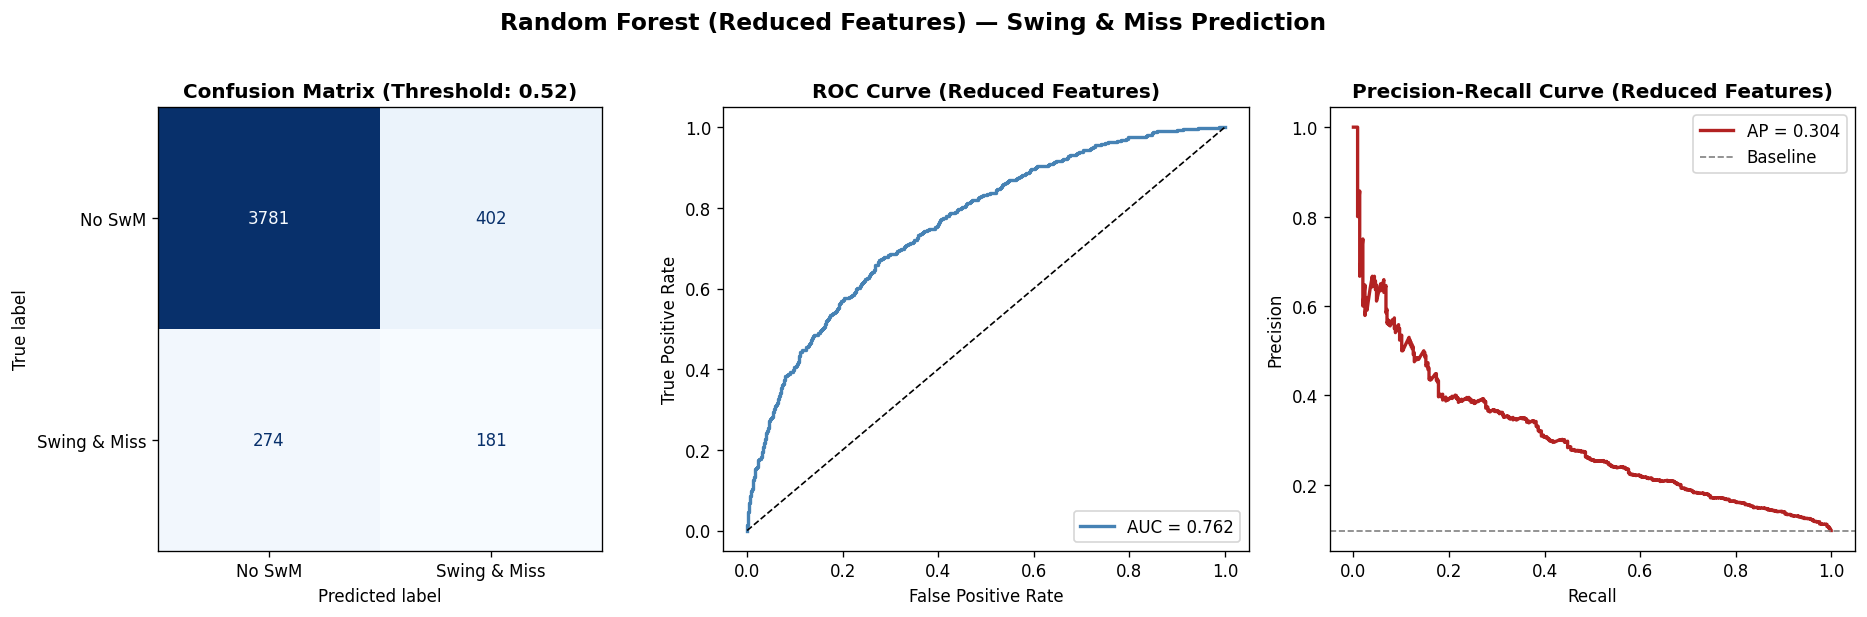

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# ── (a) Confusion Matrix ──────────────────────────────────────────────────
cm_reduced = confusion_matrix(y_test_reduced, y_pred_reduced_tuned)
disp = ConfusionMatrixDisplay(cm_reduced, display_labels=['No SwM', 'Swing & Miss'])
disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title(f'Confusion Matrix (Threshold: {chosen_threshold:.2f})', fontweight='bold')

# ── (b) ROC Curve ─────────────────────────────────────────────────────────
fpr_reduced, tpr_reduced, _ = roc_curve(y_test_reduced, y_proba_reduced)
axes[1].plot(fpr_reduced, tpr_reduced, color='steelblue', lw=2, label=f'AUC = {roc_auc_reduced:.3f}')
axes[1].plot([0,1],[0,1],'k--', lw=1)
axes[1].set_xlabel('False Positive Rate'); axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve (Reduced Features)', fontweight='bold')
axes[1].legend(loc='lower right')

# ── (c) Precision-Recall Curve ────────────────────────────────────────────
prec_reduced, rec_reduced, _ = precision_recall_curve(y_test_reduced, y_proba_reduced)
axes[2].plot(rec_reduced, prec_reduced, color='firebrick', lw=2, label=f'AP = {avg_prec_reduced:.3f}')
axes[2].axhline(y_test_reduced.mean(), color='gray', linestyle='--', lw=1, label='Baseline')
axes[2].set_xlabel('Recall'); axes[2].set_ylabel('Precision')
axes[2].set_title('Precision-Recall Curve (Reduced Features)', fontweight='bold')
axes[2].legend()

plt.suptitle('Random Forest (Reduced Features) — Swing & Miss Prediction', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

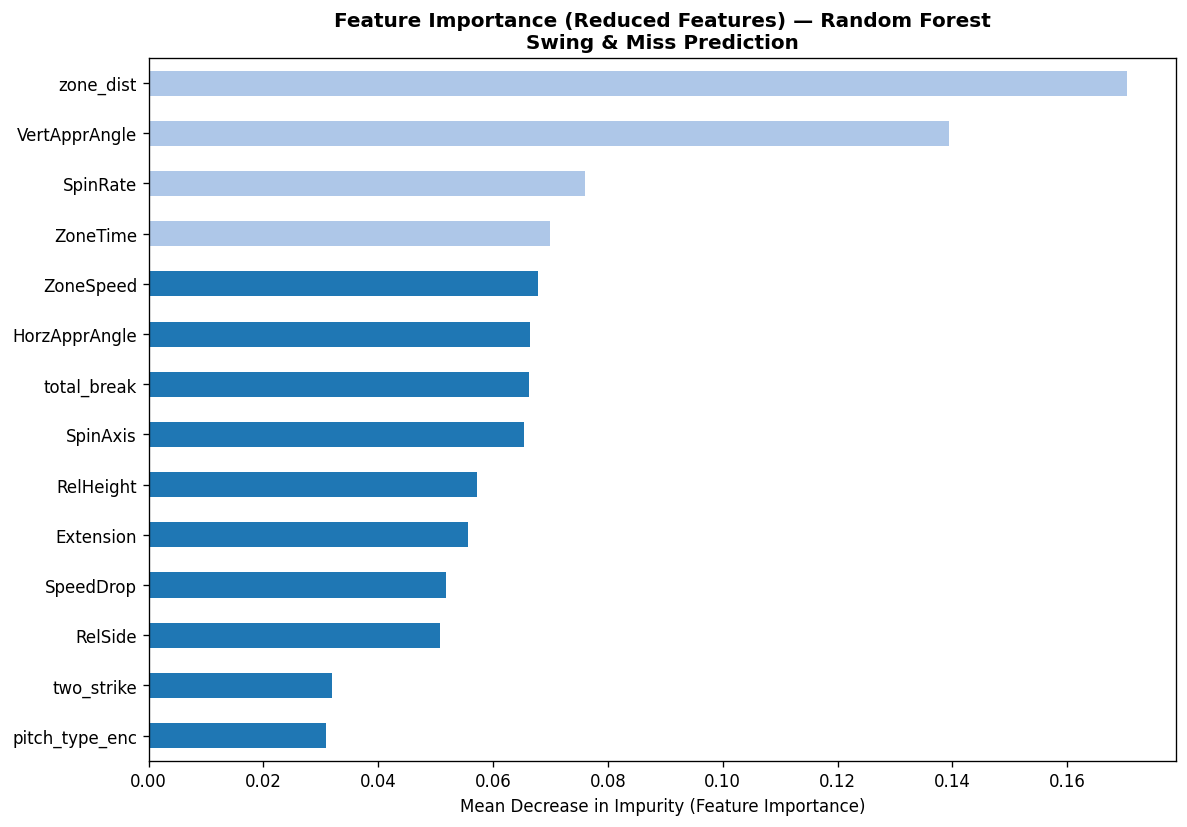

Top 10 features:
zone_dist        0.170444
VertApprAngle    0.139385
SpinRate         0.076092
ZoneTime         0.069886
ZoneSpeed        0.067875
HorzApprAngle    0.066499
total_break      0.066240
SpinAxis         0.065366
RelHeight        0.057183
Extension        0.055568


In [ ]:
importances_reduced = pd.Series(rf_reduced.feature_importances_, index=REDUCED_FEATURES)
importances_reduced = importances_reduced.sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 7))
colors = ['#1f77b4' if i < 10 else '#aec7e8' for i in range(len(importances_reduced))]
importances_reduced.plot(kind='barh', ax=ax, color=colors[::-1])
ax.invert_yaxis()
ax.set_xlabel('Mean Decrease in Impurity (Feature Importance)')
ax.set_title('Feature Importance (Reduced Features) — Random Forest\nSwing & Miss Prediction', fontweight='bold')
ax.axvline(0, color='black', lw=0.5)
plt.tight_layout()
plt.show()

print('Top 10 features:')
print(importances_reduced.head(10).to_string())

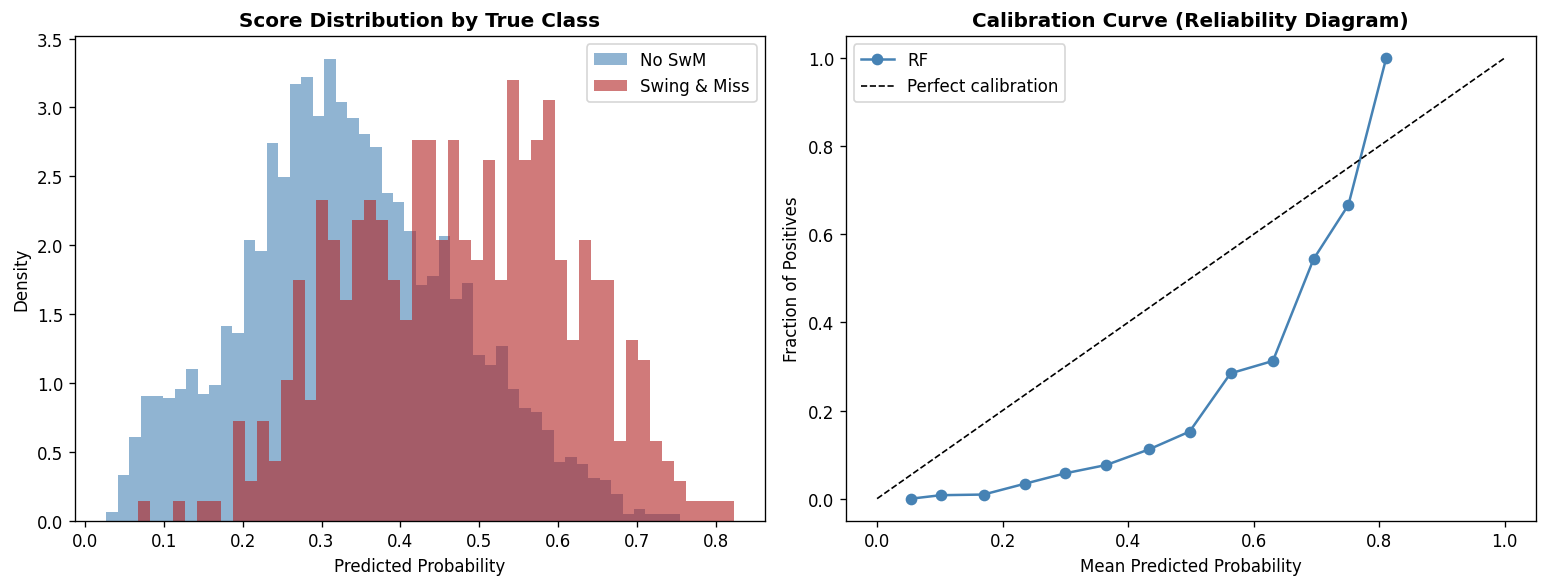

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# (a) Score distribution by true label
axes[0].hist(y_proba_reduced[y_test_reduced == 0], bins=50, alpha=0.6, color='steelblue', label='No SwM', density=True)
axes[0].hist(y_proba_reduced[y_test_reduced == 1], bins=50, alpha=0.6, color='firebrick', label='Swing & Miss', density=True)
axes[0].set_xlabel('Predicted Probability'); axes[0].set_ylabel('Density')
axes[0].set_title('Score Distribution by True Class', fontweight='bold')
axes[0].legend()

# (b) Calibration curve (reliability diagram)
frac_pos_reduced, mean_pred_reduced = calibration_curve(y_test_reduced, y_proba_reduced, n_bins=15)
axes[1].plot(mean_pred_reduced, frac_pos_reduced, marker='o', color='steelblue', label='RF')
axes[1].plot([0,1],[0,1], 'k--', lw=1, label='Perfect calibration')
axes[1].set_xlabel('Mean Predicted Probability'); axes[1].set_ylabel('Fraction of Positives')
axes[1].set_title('Calibration Curve (Reliability Diagram)', fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.show()

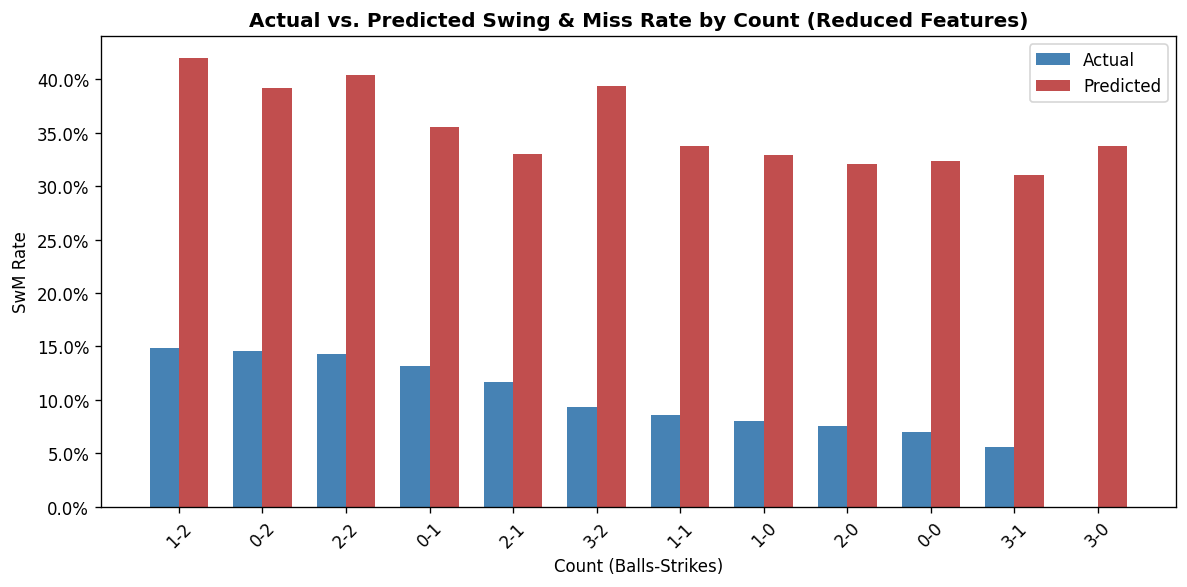

       Actual_SwM  Predicted_SwM     N
count                                 
1-2      0.148438       0.419407   384
0-2      0.145907       0.391452   281
2-2      0.143322       0.403737   307
0-1      0.131679       0.355365   524
2-1      0.116667       0.329856   240
3-2      0.093220       0.393897   236
1-1      0.085437       0.337705   515
1-0      0.080306       0.328902   523
2-0      0.075377       0.320213   199
0-0      0.069749       0.323481  1233
3-1      0.055556       0.310252   126
3-0      0.000000       0.337473    70


In [ ]:
test_df_reduced = df.loc[X_test_reduced.index, ['Balls', 'Strikes', 'swing_and_miss']].copy()
test_df_reduced['proba'] = y_proba_reduced
test_df_reduced['count'] = test_df_reduced['Balls'].astype(int).astype(str) + '-' + test_df_reduced['Strikes'].astype(int).astype(str)

count_summary_reduced = test_df_reduced.groupby('count').agg(
    Actual_SwM=('swing_and_miss', 'mean'),
    Predicted_SwM=('proba', 'mean'),
    N=('swing_and_miss', 'count')
).query('N >= 30').sort_values('Actual_SwM', ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(count_summary_reduced))
w = 0.35
ax.bar(x - w/2, count_summary_reduced['Actual_SwM'],    w, label='Actual',    color='steelblue')
ax.bar(x + w/2, count_summary_reduced['Predicted_SwM'], w, label='Predicted', color='firebrick', alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels(count_summary_reduced.index, rotation=45)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.set_title('Actual vs. Predicted Swing & Miss Rate by Count (Reduced Features)', fontweight='bold')
ax.set_xlabel('Count (Balls-Strikes)'); ax.set_ylabel('SwM Rate')
ax.legend()
plt.tight_layout()
plt.show()

print(count_summary_reduced.to_string())

In [ ]:
print('='*55)
print('   RANDOM FOREST — SWING & MISS PREDICTION SUMMARY (REDUCED FEATURES)')
print('='*55)
print(f'  Training samples :  {X_train_reduced.shape[0]:,}')
print(f'  Test samples     :  {X_test_reduced.shape[0]:,}')
print(f'  # Features       :  {X_reduced.shape[1]}')
print(f'  Estimators       :  {rf_reduced.n_estimators}')
print(f'  Max depth        :  {rf_reduced.max_depth}')
print(f'  Class weighting  :  balanced')
print(f'  Prediction Threshold: {chosen_threshold:.3f}')
print('-'*55)
print(f'  5-Fold CV AUC    :  {cv_scores_reduced.mean():.4f} ± {cv_scores_reduced.std():.4f}')
print(f'  Test ROC-AUC     :  {roc_auc_reduced:.4f}')
print(f'  Test Avg Prec    :  {avg_prec_reduced:.4f}')
print('='*55)
print('\nTop 5 predictive features:')
for i, (feat, imp) in enumerate(importances_reduced.head(5).items(), 1):
    print(f'  {i}. {feat:<25} {imp:.4f}')

   RANDOM FOREST — SWING & MISS PREDICTION SUMMARY (REDUCED FEATURES)
  Training samples :  18,550
  Test samples     :  4,638
  # Features       :  14
  Estimators       :  300
  Max depth        :  12
  Class weighting  :  balanced
  Prediction Threshold: 0.524
-------------------------------------------------------
  5-Fold CV AUC    :  0.7594 ± 0.0129
  Test ROC-AUC     :  0.7617
  Test Avg Prec    :  0.3041

Top 5 predictive features:
  1. zone_dist                 0.1704
  2. VertApprAngle             0.1394
  3. SpinRate                  0.0761
  4. ZoneTime                  0.0699
  5. ZoneSpeed                 0.0679


In [ ]:
tn_original, fp_original, fn_original, tp_original = cm.ravel()
fpr_original = fp_original / (fp_original + tn_original)

tn_reduced, fp_reduced, fn_reduced, tp_reduced = cm_reduced.ravel()
fpr_reduced = fp_reduced / (fp_reduced + tn_reduced)

diff_fpr = fpr_original - fpr_reduced

print(f"Original RF Model (at 0.5 threshold):\n  False Positive Rate (FPR): {fpr_original:.4f}")
print(f"Reduced RF Model (at tuned threshold {chosen_threshold:.3f}):\n  False Positive Rate (FPR): {fpr_reduced:.4f}")
print(f"\nDifference in FPR (Original - Reduced): {diff_fpr:.4f}")

Original RF Model (at 0.5 threshold):
  False Positive Rate (FPR): 0.1234
Reduced RF Model (at tuned threshold 0.524):
  False Positive Rate (FPR): 0.0961

Difference in FPR (Original - Reduced): 0.0273
